# Experiment (v0): SSFP PixelByPixel DeepSSFP Model

Epoch 0/100 - loss: 4.26e-04 - val_loss: 6.42e-06
Epoch 10/100 - loss: 2.38e-06 - val_loss: 1.92e-06
Epoch 20/100 - loss: 2.24e-06 - val_loss: 2.06e-06
Epoch 30/100 - loss: 2.04e-06 - val_loss: 3.24e-06
Epoch 40/100 - loss: 1.65e-06 - val_loss: 1.55e-06
Epoch 50/100 - loss: 1.80e-06 - val_loss: 4.08e-06
Epoch 60/100 - loss: 1.42e-06 - val_loss: 1.90e-06
Epoch 70/100 - loss: 1.37e-06 - val_loss: 4.33e-06
Epoch 80/100 - loss: 1.22e-06 - val_loss: 1.19e-06
Epoch 90/100 - loss: 1.49e-06 - val_loss: 7.83e-07


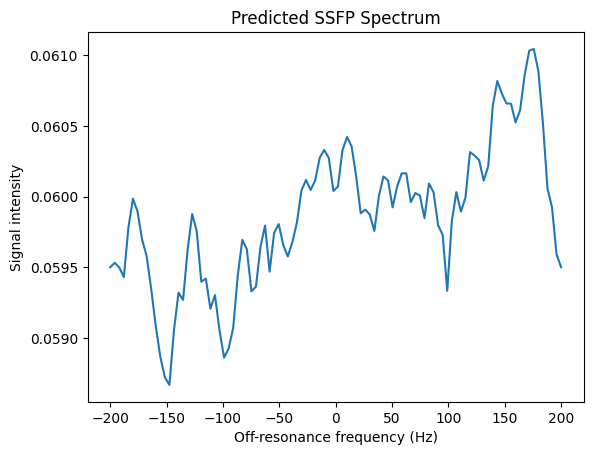

In [46]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import tensorflow as tf
from tensorflow import keras
from deepssfp import ssfp, recon

# Generate training data
def generate_training_data(num_samples=10000):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    npcs = 4
    pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M)
        y.append(np.sqrt(np.mean(np.abs(M)**2)))
    
    return np.array(X), np.array(y)

# Create the model
def create_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(4,)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")


# Train the model
def train_model(model, X, y, epochs=100, batch_size=32, print_every_n=10):
    print_callback = PrintEveryNEpoch(print_every_n)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[print_callback], verbose=0)
    return history

# Use the model to predict SSFP spectrum
def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f):
    npcs = 4
    pcs = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    spectrum = []
    for freq in f:
        M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=freq)
        spectrum.append(model.predict(M.reshape(1, -1), verbose=0)[0, 0])
    
    return np.array(spectrum)

# Example usage
def run():
    # Generate training data
    X_train, y_train = generate_training_data()
    
    # Create and train the model
    model = create_model()
    history = train_model(model, X_train, y_train)
    
    # Generate SSFP spectrum using the trained model
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)
    
    predicted_spectrum = predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f)
    
    # Plot the results
    import matplotlib.pyplot as plt
    plt.plot(f, predicted_spectrum)
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title('Predicted SSFP Spectrum')
    plt.show()

run()

# Experiment (v1): SSFP PixelByPixel DeepSSFP 
- with 2PC and 4PC data model versions

Epoch 0/100 - loss: 2.22e-04 - val_loss: 9.76e-06
Epoch 10/100 - loss: 2.45e-06 - val_loss: 2.12e-06
Epoch 20/100 - loss: 2.87e-06 - val_loss: 3.71e-06
Epoch 30/100 - loss: 2.86e-06 - val_loss: 3.10e-06
Epoch 40/100 - loss: 2.48e-06 - val_loss: 1.82e-06
Epoch 50/100 - loss: 2.81e-06 - val_loss: 2.12e-06
Epoch 60/100 - loss: 2.03e-06 - val_loss: 2.04e-06
Epoch 70/100 - loss: 2.09e-06 - val_loss: 1.87e-06
Epoch 80/100 - loss: 1.85e-06 - val_loss: 1.74e-06
Epoch 90/100 - loss: 1.67e-06 - val_loss: 2.08e-06
Epoch 0/100 - loss: 1.23e-03 - val_loss: 4.90e-04
Epoch 10/100 - loss: 2.65e-04 - val_loss: 2.10e-04
Epoch 20/100 - loss: 1.65e-04 - val_loss: 1.43e-04
Epoch 30/100 - loss: 1.51e-04 - val_loss: 1.69e-04
Epoch 40/100 - loss: 1.50e-04 - val_loss: 1.22e-04
Epoch 50/100 - loss: 1.37e-04 - val_loss: 1.15e-04
Epoch 60/100 - loss: 1.33e-04 - val_loss: 1.38e-04
Epoch 70/100 - loss: 1.19e-04 - val_loss: 1.42e-04
Epoch 80/100 - loss: 1.23e-04 - val_loss: 1.50e-04
Epoch 90/100 - loss: 1.23e-04 - v

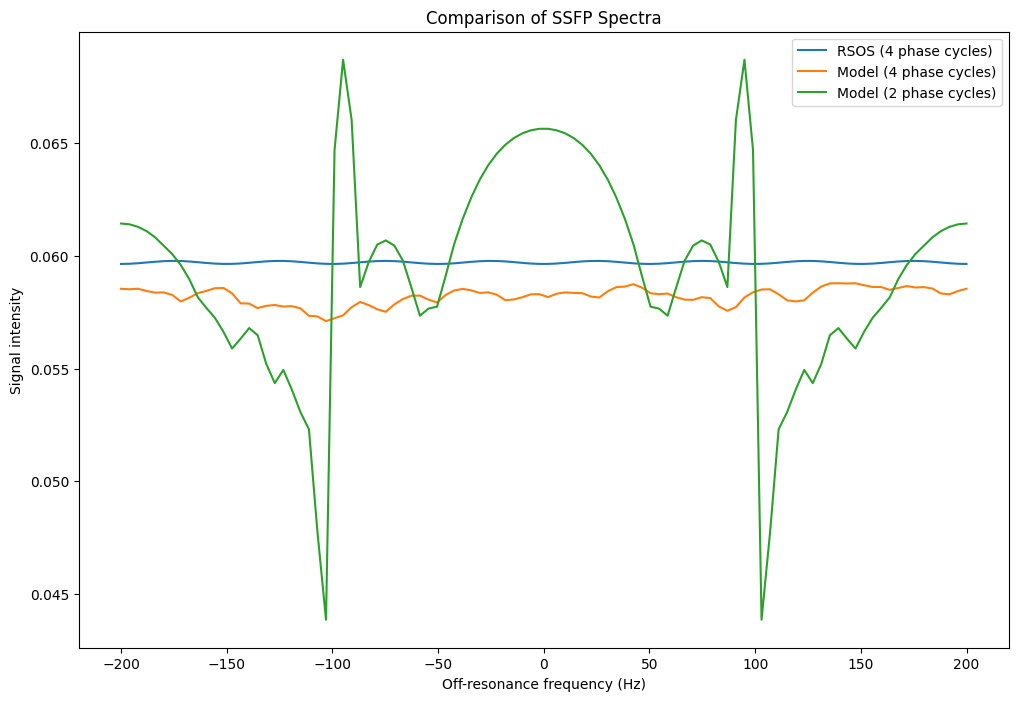

MSE (4 phase cycles): 2.385750769175362e-06
MSE (2 phase cycles): 2.137486048997474e-05


In [47]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from deepssfp import ssfp, recon

def generate_training_data(num_samples=10000, num_pcs=2):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_2pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        X.append(M_2pc)
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        y.append(np.sqrt(np.mean(np.abs(M_4pc)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model(model, X, y, epochs=100, batch_size=32, print_every_n=10):
    print_callback = PrintEveryNEpoch(print_every_n)
    history = model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2, callbacks=[print_callback], verbose=0)
    return history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    spectrum = []
    for freq in f:
        M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=freq)
        spectrum.append(model.predict(M.reshape(1, -1), verbose=0)[0, 0])
    
    return np.array(spectrum)

# Generate data and train models
X_train_4pc, y_train_4pc = generate_training_data(num_samples=10000, num_pcs=4)
X_train_2pc, y_train_2pc = generate_training_data(num_samples=10000, num_pcs=2)

model_4pc = create_model(input_shape=(4,))
model_2pc = create_model(input_shape=(2,))

history_4pc = train_model(model_4pc, X_train_4pc, y_train_4pc)
history_2pc = train_model(model_2pc, X_train_2pc, y_train_2pc)

# Generate SSFP spectrum for comparison
T1, T2 = 1.2, 0.035
TR, alpha = 5e-3, np.deg2rad(30)
TE = TR / 2.0
BetaMax = 2 * np.pi
beta = np.linspace(-BetaMax, BetaMax, 100)
f = beta / TR / (2 * np.pi)

predicted_spectrum_4pc = predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4)
predicted_spectrum_2pc = predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2)

# Calculate RSOS spectrum
M_4pc = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
rsos_spectrum = np.sqrt(np.mean(np.abs(M_4pc)**2, axis=1))

# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)')
plt.plot(f, predicted_spectrum_4pc, label='Model (4 phase cycles)')
plt.plot(f, predicted_spectrum_2pc, label='Model (2 phase cycles)')
plt.xlabel('Off-resonance frequency (Hz)')
plt.ylabel('Signal intensity')
plt.title('Comparison of SSFP Spectra')
plt.legend()
plt.show()

# Calculate and print mean squared errors
mse_4pc = np.mean((rsos_spectrum - predicted_spectrum_4pc)**2)
mse_2pc = np.mean((rsos_spectrum - predicted_spectrum_2pc)**2)
print(f"MSE (4 phase cycles): {mse_4pc}")
print(f"MSE (2 phase cycles): {mse_2pc}")

# Experiment (v2): SSFP PixelByPixel DeepSSFP Model
- Uses standard scaler to normalize data
- Improved model architecture with batch normalization
- Early stopping
- Added noise
- Academic metrics i.e. MSE, PSNR, SSIM
- Predict SSFP spectrum with multiple acquisitions
- Printing Loss Metrics Every N Epochs
- Log loss plots


Creating training data...
Completed in 9.85 seconds.
Training 4PC model...
Epoch 0/200 - loss: 4.66e-02 - val_loss: 7.09e-03
Epoch 10/200 - loss: 4.32e-04 - val_loss: 3.30e-04
Epoch 20/200 - loss: 2.22e-04 - val_loss: 1.92e-04
Epoch 30/200 - loss: 1.57e-04 - val_loss: 1.12e-04
Epoch 40/200 - loss: 1.26e-04 - val_loss: 1.10e-04
Epoch 50/200 - loss: 1.14e-04 - val_loss: 1.36e-04
Epoch 60/200 - loss: 9.40e-05 - val_loss: 3.66e-05
Completed in 49.74 seconds.
Training 2PC model...
Epoch 0/200 - loss: 3.54e-02 - val_loss: 5.01e-03
Epoch 10/200 - loss: 5.87e-04 - val_loss: 7.67e-04
Epoch 20/200 - loss: 4.85e-04 - val_loss: 3.43e-04
Epoch 30/200 - loss: 3.86e-04 - val_loss: 3.29e-04
Epoch 40/200 - loss: 3.62e-04 - val_loss: 3.27e-04
Epoch 50/200 - loss: 3.44e-04 - val_loss: 3.47e-04
Epoch 60/200 - loss: 3.45e-04 - val_loss: 2.94e-04
Epoch 70/200 - loss: 3.43e-04 - val_loss: 3.13e-04
Epoch 80/200 - loss: 3.31e-04 - val_loss: 3.09e-04
Completed in 58.44 seconds.
Predicting spectra...
Prediction 

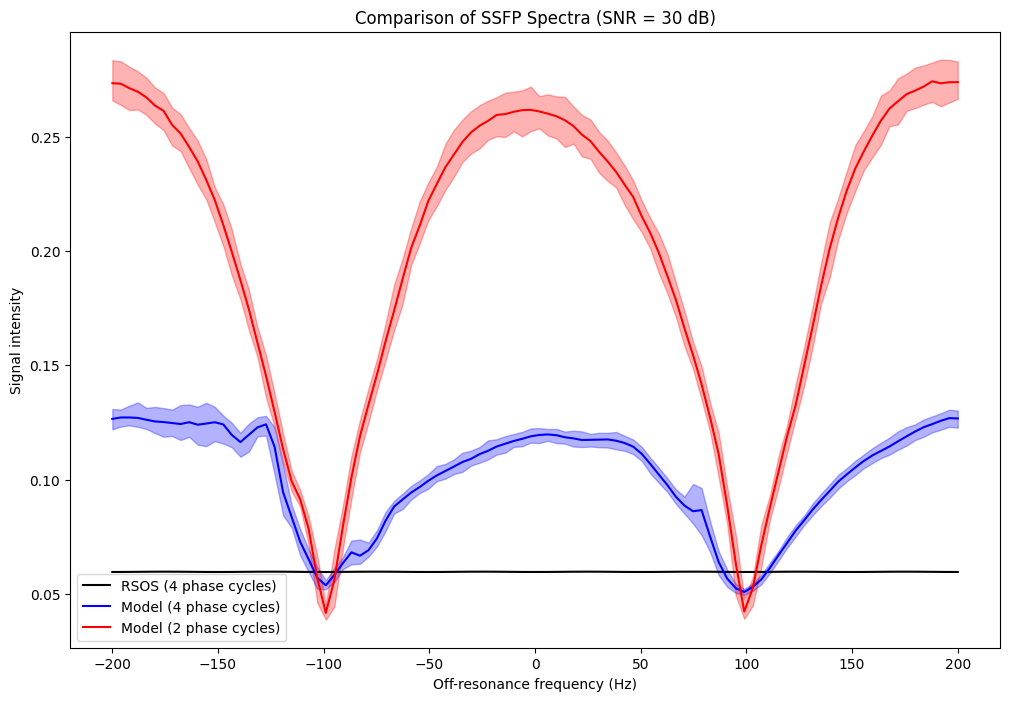

Metrics for 4 phase cycle model:
MSE: 2.28e-03
RMSE: 4.78e-02
MAE: 4.26e-02
R2: -9.83e+05
Correlation: 5.65e-02
NRMSE: 3.52e+02

Metrics for 2 phase cycle model:
MSE: 2.39e-02
RMSE: 1.54e-01
MAE: 1.39e-01
R2: -1.03e+07
Correlation: 3.71e-02
NRMSE: 1.14e+03

Paired t-test results:
t-statistic: -1.42e+03
p-value: 3.86e-215


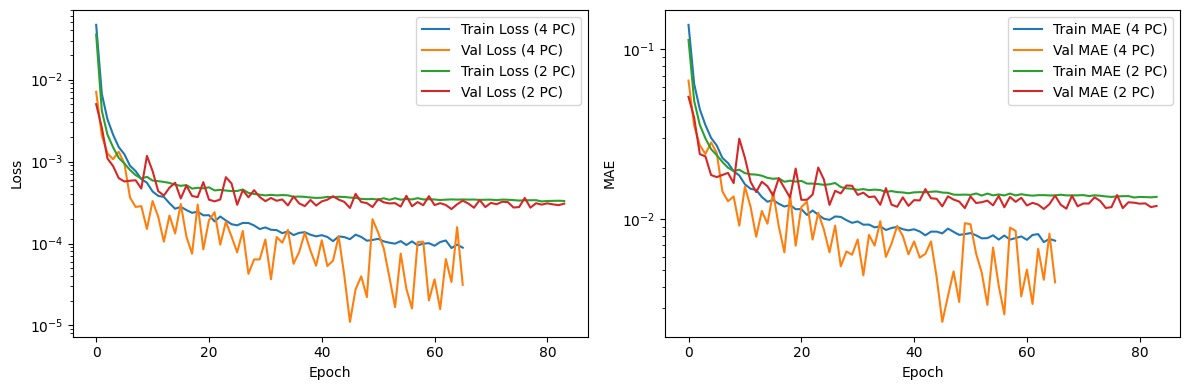

In [8]:
import sys
sys.path.insert(0, '../../')
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):
    T1 = np.random.uniform(0.5, 2.0, num_samples)
    T2 = np.random.uniform(0.01, 0.1, num_samples)
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2 * np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model(X, y, epochs=200, batch_size=32, validation_split=0.2, print_every_n=10):
    model = create_model(input_shape=(X.shape[1],))
    
    early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
    print_callback = PrintEveryNEpoch(print_every_n)
    
    history = model.fit(X, y, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=validation_split,
                        callbacks=[early_stopping, print_callback],
                        verbose=0)
    
    return model, history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    # Generate SSFP signals for all frequencies at once
    M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
    
    # Add noise to all signals
    M_noisy = add_noise(M, snr)
    
    # Reshape and prepare input for the model
    M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)], axis=1)
    M_scaled = scaler.transform(M_input)
    
    # Predict all spectra at once
    predictions = model.predict(M_scaled, verbose=0)
    
    return predictions.flatten()

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):

    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Generate data and preprocess
    print('Creating training data...')
    start_time = time.time()
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)
    #X_2pc = X_4pc[:, [0, 2, 4, 6]]; y_2pc = y_4pc
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)

    # Train models
    print('Training 4PC model...')
    start_time = time.time()
    model_4pc, history_4pc = train_model(X_4pc_scaled, y_4pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))
    print('Training 2PC model...')
    start_time = time.time()
    model_2pc, history_2pc = train_model(X_2pc_scaled, y_2pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    # Generate SSFP spectra for comparison
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    num_samples = 100
    print('Predicting spectra...')
    start_time = time.time()
    predicted_spectra_4pc = np.array([predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr) for _ in range(num_samples)])
    predicted_spectra_2pc = np.array([predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr) for _ in range(num_samples)])
    print('Prediction completed in %.2f seconds.' % (time.time() - start_time))

    # Calculate average and confidence intervals
    avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
    ci_4pc = np.percentile(predicted_spectra_4pc, [2.5, 97.5], axis=0)

    avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)
    ci_2pc = np.percentile(predicted_spectra_2pc, [2.5, 97.5], axis=0)

    # Calculate RSOS spectrum
    rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
    rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

    # Plot the results
    plt.figure(figsize=(12, 8))
    plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
    plt.plot(f, avg_spectrum_4pc, label='Model (4 phase cycles)', color='blue')
    plt.fill_between(f, ci_4pc[0], ci_4pc[1], alpha=0.3, color='blue')
    plt.plot(f, avg_spectrum_2pc, label='Model (2 phase cycles)', color='red')
    plt.fill_between(f, ci_2pc[0], ci_2pc[1], alpha=0.3, color='red')
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title(f'Comparison of SSFP Spectra (SNR = {snr} dB)')
    plt.legend()
    plt.show()

    # Calculate and print metrics
    metrics_4pc = calculate_metrics(rsos_spectrum, avg_spectrum_4pc)
    metrics_2pc = calculate_metrics(rsos_spectrum, avg_spectrum_2pc)

    print("Metrics for 4 phase cycle model:")
    for metric, value in metrics_4pc.items():
        print(f"{metric}: {value:.2e}")

    print("\nMetrics for 2 phase cycle model:")
    for metric, value in metrics_2pc.items():
        print(f"{metric}: {value:.2e}")

    # Statistical analysis
    t_statistic, p_value = ttest_rel(
        np.mean((rsos_spectrum - predicted_spectra_4pc)**2, axis=1),
        np.mean((rsos_spectrum - predicted_spectra_2pc)**2, axis=1)
    )

    print(f"\nPaired t-test results:")
    print(f"t-statistic: {t_statistic:.2e}")
    print(f"p-value: {p_value:.2e}")

    # Plot average training history
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.semilogy(history_4pc.history['loss'], label='Train Loss (4 PC)')
    plt.semilogy(history_4pc.history['val_loss'], label='Val Loss (4 PC)')
    plt.semilogy(history_2pc.history['loss'], label='Train Loss (2 PC)')
    plt.semilogy(history_2pc.history['val_loss'], label='Val Loss (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(122)
    plt.semilogy(history_4pc.history['mae'], label='Train MAE (4 PC)')
    plt.semilogy(history_4pc.history['val_mae'], label='Val MAE (4 PC)')
    plt.semilogy(history_2pc.history['mae'], label='Train MAE (2 PC)')
    plt.semilogy(history_2pc.history['val_mae'], label='Val MAE (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()

run()

# Experiment (v3): SSFP PixelByPixel DeepSSFP Model
- Updated T1 and T2 sampling
- Comparison with common tissue types

Creating training data...
Completed in 9.79 seconds.
Training 4PC model...
Epoch 0/200 - loss: 3.75e-02 - val_loss: 5.03e-03
Epoch 10/200 - loss: 9.30e-04 - val_loss: 4.54e-04
Epoch 20/200 - loss: 6.77e-04 - val_loss: 2.01e-04
Epoch 30/200 - loss: 5.42e-04 - val_loss: 3.73e-04
Epoch 40/200 - loss: 4.40e-04 - val_loss: 1.78e-04
Epoch 50/200 - loss: 4.36e-04 - val_loss: 2.15e-04
Epoch 60/200 - loss: 3.37e-04 - val_loss: 3.07e-04
Epoch 70/200 - loss: 3.54e-04 - val_loss: 1.26e-04
Epoch 80/200 - loss: 3.31e-04 - val_loss: 1.57e-04
Epoch 90/200 - loss: 3.14e-04 - val_loss: 1.98e-04
Completed in 70.14 seconds.
Training 2PC model...
Epoch 0/200 - loss: 4.87e-02 - val_loss: 8.17e-03
Epoch 10/200 - loss: 1.81e-03 - val_loss: 1.28e-03
Epoch 20/200 - loss: 1.42e-03 - val_loss: 1.02e-03
Epoch 30/200 - loss: 1.23e-03 - val_loss: 1.01e-03
Epoch 40/200 - loss: 1.12e-03 - val_loss: 1.04e-03
Epoch 50/200 - loss: 1.10e-03 - val_loss: 9.44e-04
Completed in 40.87 seconds.


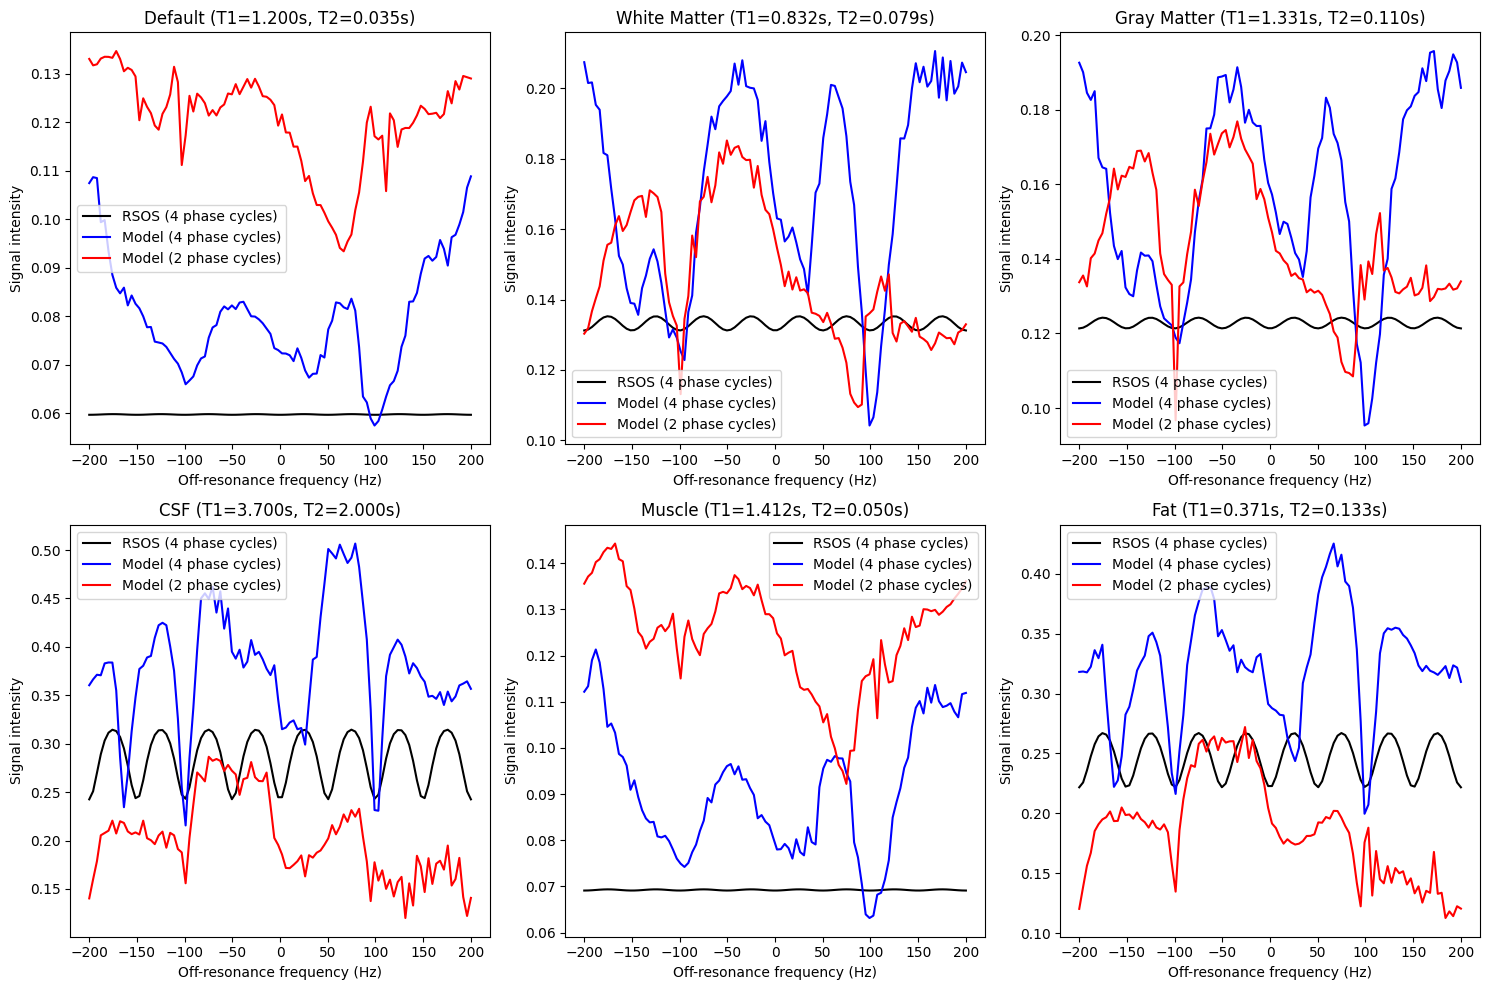

Predicting spectra...
Prediction completed in 10.04 seconds.


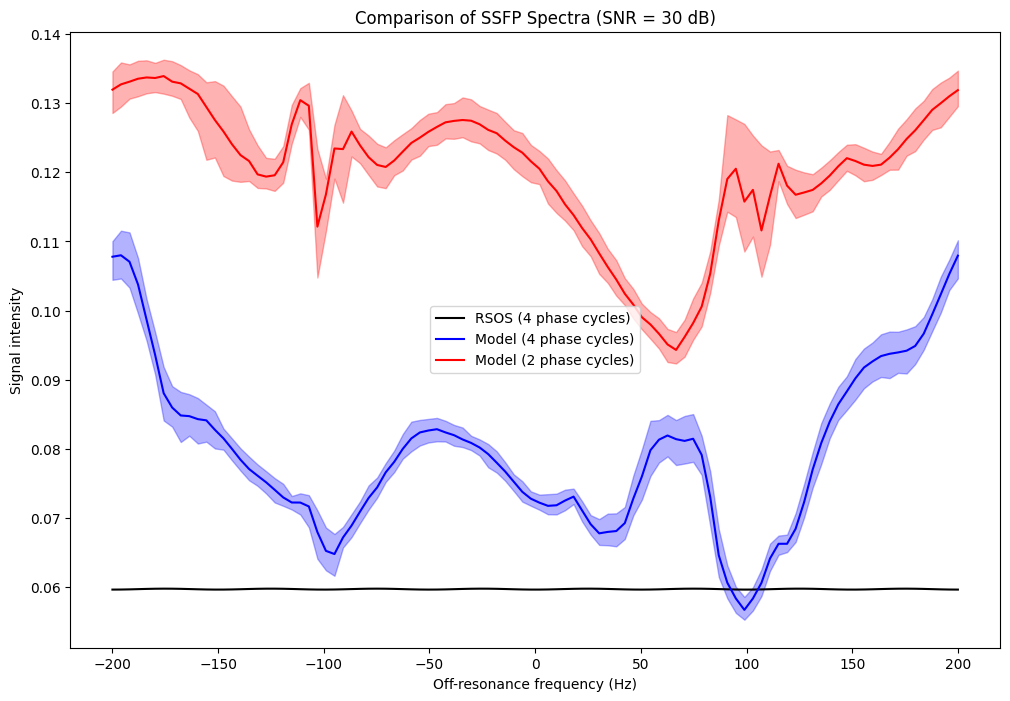

Metrics for 4 phase cycle model:
MSE: 5.31e-04
RMSE: 2.30e-02
MAE: 2.00e-02
R2: -2.29e+05
Correlation: -4.12e-02
NRMSE: 1.70e+02

Metrics for 2 phase cycle model:
MSE: 3.76e-03
RMSE: 6.13e-02
MAE: 6.06e-02
R2: -1.62e+06
Correlation: -6.82e-02
NRMSE: 4.52e+02

Paired t-test results:
t-statistic: -1.31e+03
p-value: 1.00e-211


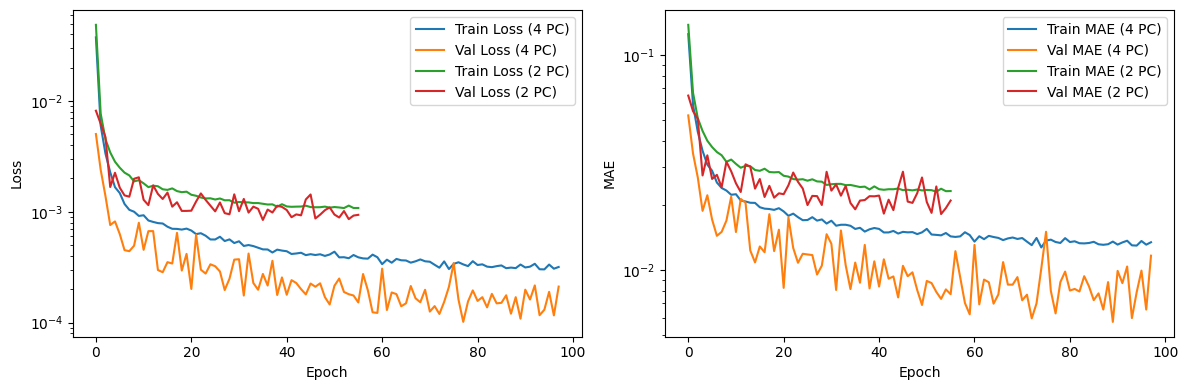

In [9]:
import sys
sys.path.insert(0, '../../')
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):

    def sample_t1_t2(num_samples, ratio_min=0.5, ratio_max=20, t1_min=0.1, t1_max=2.0):
        #T1 = np.random.uniform(0.5, 2.0, num_samples)
        #T2 = np.random.uniform(0.01, 0.1, num_samples)

        ratios = np.random.uniform(ratio_min, ratio_max, num_samples)
        T1 = np.random.uniform(t1_min, t1_max, num_samples)
        T2 = T1 / ratios
        return T1, T2, ratios
    
    T1, T2, ratios = sample_t1_t2(num_samples)
    
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, 2*np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")


def train_model(X, y, epochs=200, batch_size=32, validation_split=0.2, print_every_n=10):
    model = create_model(input_shape=(X.shape[1],))
    
    early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
    print_callback = PrintEveryNEpoch(print_every_n)
    
    history = model.fit(X, y, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=validation_split,
                        callbacks=[early_stopping, print_callback],
                        verbose=0)
    
    return model, history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    # Generate SSFP signals for all frequencies at once
    M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
    
    # Add noise to all signals
    M_noisy = add_noise(M, snr)
    
    # Reshape and prepare input for the model
    M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)], axis=1)
    M_scaled = scaler.transform(M_input)
    
    # Predict all spectra at once
    predictions = model.predict(M_scaled, verbose=0)
    
    return predictions.flatten()

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

def train_models(snr, num_samples, epochs, batch_size, print_every_n):
    # Generate data and preprocess
    print('Creating training data...')
    start_time = time.time()
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)
    #X_2pc = X_4pc[:, [0, 2, 4, 6]]; y_2pc = y_4pc
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)

    # Train models
    print('Training 4PC model...')
    start_time = time.time()
    model_4pc, history_4pc = train_model(X_4pc_scaled, y_4pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))
    print('Training 2PC model...')
    start_time = time.time()
    model_2pc, history_2pc = train_model(X_2pc_scaled, y_2pc, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    return model_4pc, model_2pc, scaler_4pc, scaler_2pc, history_4pc, history_2pc

def test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr):
    # Common tissue types (T1 and T2 values in seconds at 3T)
    tissues = {
        'Default': (1.2, 0.035),
        'White Matter': (0.832, 0.079),
        'Gray Matter': (1.331, 0.110),
        'CSF': (3.700, 2.000),
        'Muscle': (1.412, 0.050),
        'Fat': (0.371, 0.133)
    }

    # Generate SSFP spectra for common tissue types
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    plt.figure(figsize=(15, 10))
    for i, (tissue, (T1, T2)) in enumerate(tissues.items()):
        predicted_spectra_4pc = predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr)
        predicted_spectra_2pc = predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr)

        rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
        rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

        plt.subplot(2, 3, i+1)
        plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
        plt.plot(f, predicted_spectra_4pc, label='Model (4 phase cycles)', color='blue')
        plt.plot(f, predicted_spectra_2pc, label='Model (2 phase cycles)', color='red')
        plt.xlabel('Off-resonance frequency (Hz)')
        plt.ylabel('Signal intensity')
        plt.title(f'{tissue} (T1={T1:.3f}s, T2={T2:.3f}s)')
        plt.legend()

    plt.tight_layout()
    plt.show()
    
def test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr):
    # Generate SSFP spectra for comparison
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    num_samples = 100
    print('Predicting spectra...')
    start_time = time.time()
    predicted_spectra_4pc = np.array([predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr) for _ in range(num_samples)])
    predicted_spectra_2pc = np.array([predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr) for _ in range(num_samples)])
    print('Prediction completed in %.2f seconds.' % (time.time() - start_time))

    # Calculate average and confidence intervals
    avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
    ci_4pc = np.percentile(predicted_spectra_4pc, [2.5, 97.5], axis=0)

    avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)
    ci_2pc = np.percentile(predicted_spectra_2pc, [2.5, 97.5], axis=0)

    # Calculate RSOS spectrum
    rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
    rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

    # Plot the results
    plt.figure(figsize=(12, 8))
    plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
    plt.plot(f, avg_spectrum_4pc, label='Model (4 phase cycles)', color='blue')
    plt.fill_between(f, ci_4pc[0], ci_4pc[1], alpha=0.3, color='blue')
    plt.plot(f, avg_spectrum_2pc, label='Model (2 phase cycles)', color='red')
    plt.fill_between(f, ci_2pc[0], ci_2pc[1], alpha=0.3, color='red')
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title(f'Comparison of SSFP Spectra (SNR = {snr} dB)')
    plt.legend()
    plt.show()

    # Calculate and print metrics
    metrics_4pc = calculate_metrics(rsos_spectrum, avg_spectrum_4pc)
    metrics_2pc = calculate_metrics(rsos_spectrum, avg_spectrum_2pc)

    print("Metrics for 4 phase cycle model:")
    for metric, value in metrics_4pc.items():
        print(f"{metric}: {value:.2e}")

    print("\nMetrics for 2 phase cycle model:")
    for metric, value in metrics_2pc.items():
        print(f"{metric}: {value:.2e}")

    # Statistical analysis
    t_statistic, p_value = ttest_rel(
        np.mean((rsos_spectrum - predicted_spectra_4pc)**2, axis=1),
        np.mean((rsos_spectrum - predicted_spectra_2pc)**2, axis=1)
    )

    print(f"\nPaired t-test results:")
    print(f"t-statistic: {t_statistic:.2e}")
    print(f"p-value: {p_value:.2e}")

def plot_training_history(history_4pc, history_2pc):

    # Plot average training history
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.semilogy(history_4pc.history['loss'], label='Train Loss (4 PC)')
    plt.semilogy(history_4pc.history['val_loss'], label='Val Loss (4 PC)')
    plt.semilogy(history_2pc.history['loss'], label='Train Loss (2 PC)')
    plt.semilogy(history_2pc.history['val_loss'], label='Val Loss (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(122)
    plt.semilogy(history_4pc.history['mae'], label='Train MAE (4 PC)')
    plt.semilogy(history_4pc.history['val_mae'], label='Val MAE (4 PC)')
    plt.semilogy(history_2pc.history['mae'], label='Train MAE (2 PC)')
    plt.semilogy(history_2pc.history['val_mae'], label='Val MAE (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()


def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)

    # Run experiments
    model_4pc, model_2pc, scaler_4pc, scaler_2pc, history_4pc, history_2pc = train_models(snr, num_samples, epochs, batch_size, print_every_n)
    test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
    test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
    plot_training_history(history_4pc, history_2pc)

# Main execution
run()

# Experiment (v4): SSFP PixelByPixel DeepSSFP Model
- Architectures: Dense, ResNet, Attention, Diffusion

In [5]:
import sys
sys.path.insert(0, '../../')
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, ttest_rel
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from deepssfp import ssfp, recon

def add_noise(signal, snr):
    signal_power = np.mean(np.abs(signal)**2)
    noise_power = signal_power / (10**(snr/10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j * np.random.randn(*signal.shape))
    return signal + noise

def generate_training_data(num_samples=10000, num_pcs=2, snr=30):

    def sample_t1_t2(num_samples, ratio_min=0.5, ratio_max=20, t1_min=0.1, t1_max=2.0):
        #T1 = np.random.uniform(0.5, 2.0, num_samples)
        #T2 = np.random.uniform(0.01, 0.1, num_samples)

        ratios = np.random.uniform(ratio_min, ratio_max, num_samples)
        T1 = np.random.uniform(t1_min, t1_max, num_samples)
        T2 = T1 / ratios
        return T1, T2, ratios
    
    T1, T2, ratios = sample_t1_t2(num_samples)
    
    TR = 5e-3
    alpha = np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.random.uniform(-BetaMax, BetaMax, num_samples)
    f = beta / TR / (2 * np.pi)
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    X = []
    y = []
    
    for i in range(num_samples):
        M_input = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, pcs, f0=f[i])
        M_input_noisy = add_noise(M_input, snr)
        X.append(np.concatenate([np.real(M_input_noisy), np.imag(M_input_noisy)]))
        
        M_4pc = ssfp.ssfp(T1[i], T2[i], TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f[i])
        M_4pc_noisy = add_noise(M_4pc, snr)
        y.append(np.sqrt(np.mean(np.abs(M_4pc_noisy)**2)))
    
    return np.array(X), np.array(y)

def create_dense_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_improved_model(input_shape):
    
    inputs = keras.layers.Input(shape=input_shape)
    x = inputs
    
    for units in [128, 64, 32, 16]:
        x = keras.layers.Dense(units)(x)                # Dense layer
        x = keras.layers.BatchNormalization()(x)        # Batch Normalization
        x = keras.layers.LeakyReLU(alpha=0.1)(x)        # Activation
        x = keras.layers.Dropout(0.2)(x)                # Dropout
        
        # Residual connection
        if x.shape[-1] == units:
            x = keras.layers.Add()([x, inputs])  # Only add if shapes match
    
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Learning rate schedule
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        decay_rate=0.9)
    
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])
    
    return model


def create_deep_model(input_shape, num_layers=10):
    inputs = keras.layers.Input(shape=input_shape)
    x = inputs
    
    # Initial wide layer
    x = keras.layers.Dense(256)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.LeakyReLU(alpha=0.1)(x)
    
    # Deep stack of layers
    for i in range(num_layers):
        units = 256 // (2 ** (i // 3))  # Gradually decrease units
        
        # Dense layer
        x = keras.layers.Dense(units)(x)
        
        # Batch Normalization
        x = keras.layers.BatchNormalization()(x)
        
        # Activation
        x = keras.layers.LeakyReLU(alpha=0.1)(x)
        
        # Dropout (with decreasing rate)
        dropout_rate = 0.5 * (1 - i / num_layers)
        x = keras.layers.Dropout(dropout_rate)(x)
        
        # Residual connection every 3 layers
        if i % 3 == 2 and x.shape[-1] == inputs.shape[-1]:
            x = keras.layers.Add()([x, inputs])
    
    # Final layers
    x = keras.layers.Dense(32)(x)
    x = keras.layers.LeakyReLU(alpha=0.1)(x)
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Learning rate schedule
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=10000,
        decay_rate=0.95)
    
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])
    
    return model

def create_1dconv_model(input_shape):
    print(input_shape)
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Reshape((input_shape[0], 1)),

        # First convolutional block
        keras.layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        keras.layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        keras.layers.MaxPooling1D(pool_size=2),
        
        # Second convolutional block
        keras.layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        keras.layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        keras.layers.MaxPooling1D(pool_size=2),
        
        # Third convolutional block
        keras.layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        keras.layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        keras.layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        #keras.layers.MaxPooling1D(pool_size=2),
        
        # Flatten and dense layers
        keras.layers.Flatten(),
        keras.layers.Dense(512, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(1)  # Output layer
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_symmetric_conv1d_model(input_shape):
    model = keras.Sequential([
        keras.layers.Input(shape=input_shape),
        keras.layers.Reshape((input_shape[0], 1)),

        # Encoder (increasing filters)
        keras.layers.Conv1D(64, kernel_size=3, activation='swish', padding='same'),
        keras.layers.Conv1D(128, kernel_size=3, activation='swish', padding='same'),
        keras.layers.Conv1D(256, kernel_size=3, activation='swish', padding='same'),
        keras.layers.Conv1D(512, kernel_size=3, activation='swish', padding='same'),
        
        # Bridge
        keras.layers.Conv1D(512, kernel_size=3, activation='swish', padding='same'),
        
        # Decoder (decreasing filters)
        keras.layers.Conv1D(256, kernel_size=3, activation='swish', padding='same'),
        keras.layers.Conv1D(128, kernel_size=3, activation='swish', padding='same'),
        keras.layers.Conv1D(64, kernel_size=3, activation='swish', padding='same'),
        
        # Output layers
        keras.layers.GlobalAveragePooling1D(),  # Alternative to Flatten
        keras.layers.Dense(64, activation='swish'),  # Additional dense layer
        keras.layers.Dense(32, activation='swish'),  # Additional dense layer
        keras.layers.Dense(1)
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_unet_1dconv_model(input_shape):
    def conv1d_block(inputs, filters, kernel_size=3, activation='relu'):
        x = keras.layers.Conv1D(filters, kernel_size, padding='same')(inputs)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation(activation)(x)
        x = keras.layers.Conv1D(filters, kernel_size, padding='same')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Activation(activation)(x)
        return x

    inputs = keras.layers.Input(input_shape)
    inputs_reshaped = keras.layers.Reshape((input_shape[0], 1))(inputs)

    # Encoder (Downsampling)
    conv1 = conv1d_block(inputs_reshaped, 32)
    pool1 = keras.layers.MaxPooling1D(pool_size=2)(conv1)  # 4x1

    conv2 = conv1d_block(pool1, 64)
    pool2 = keras.layers.MaxPooling1D(pool_size=2)(conv2)  # 2x1

    # Bridge
    conv3 = conv1d_block(pool2, 128)

    # Decoder (Upsampling)
    up4 = keras.layers.Conv1DTranspose(64, 2, strides=2, padding='same')(conv3)  # 4x1
    up4 = keras.layers.concatenate([up4, conv2])
    conv4 = conv1d_block(up4, 64)

    up5 = keras.layers.Conv1DTranspose(32, 2, strides=2, padding='same')(conv4)  # 8x1
    up5 = keras.layers.concatenate([up5, conv1])
    conv5 = conv1d_block(up5, 32)

    outputs = keras.layers.Conv1D(1, 1)(conv5)  # Linear activation for regression
    outputs = keras.layers.Reshape((input_shape[0],))(outputs)

    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_resnet_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Dense(64, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    
    for _ in range(3):  # Number of residual blocks
        residual = x
        x = keras.layers.Dense(64, activation='relu')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Dense(64, activation='relu')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Add()([x, residual])
    
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_attention_model(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Dense(64, activation='relu')(inputs)
    x = keras.layers.BatchNormalization()(x)
    
    # Self-attention layer
    query = keras.layers.Dense(64)(x)
    key = keras.layers.Dense(64)(x)
    value = keras.layers.Dense(64)(x)
    attention_scores = tf.matmul(query, key, transpose_b=True)
    attention_scores = tf.nn.softmax(attention_scores, axis=-1)
    attention_output = tf.matmul(attention_scores, value)
    
    x = keras.layers.Concatenate()([x, attention_output])
    x = keras.layers.Dense(64, activation='relu')(x)
    x = keras.layers.BatchNormalization()(x)
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

def create_vit_model(input_shape, patch_size=4, num_heads=8, mlp_dim=64, num_layers=6):
    def mlp(x, hidden_units, dropout_rate):
        for units in hidden_units:
            x = keras.layers.Dense(units, activation=tf.nn.gelu)(x)
            x = keras.layers.Dropout(dropout_rate)(x)
        return x

    inputs = keras.layers.Input(input_shape)
    
    # Split into patches
    patches = keras.layers.Reshape((input_shape[0] // patch_size, patch_size))(inputs)
    
    # Embed patches
    patch_embed_dim = mlp_dim
    x = keras.layers.Dense(patch_embed_dim)(patches)
    
    # Add position embeddings
    positions = tf.range(start=0, limit=input_shape[0] // patch_size, delta=1)
    pos_embed = keras.layers.Embedding(input_dim=input_shape[0] // patch_size, output_dim=patch_embed_dim)(positions)
    x = x + pos_embed
    
    # Transformer blocks
    for _ in range(num_layers):
        # Multi-head attention
        attn_output = keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=patch_embed_dim // num_heads)(x, x)
        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn_output)
        
        # MLP
        mlp_output = mlp(x, hidden_units=[mlp_dim, patch_embed_dim], dropout_rate=0.1)
        x = keras.layers.LayerNormalization(epsilon=1e-6)(x + mlp_output)
    
    # Global average pooling and output
    x = keras.layers.GlobalAveragePooling1D()(x)
    outputs = keras.layers.Dense(1)(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse',
                  metrics=['mae'])
    return model

class PrintEveryNEpoch(keras.callbacks.Callback):
    def __init__(self, n):
        super().__init__()
        self.n = n

    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.n == 0:
            print(f"Epoch {epoch}/{self.params['epochs']} - loss: {logs['loss']:.2e} - val_loss: {logs['val_loss']:.2e}")

def train_model(X, y, create_model_func, epochs=200, batch_size=32, validation_split=0.2, print_every_n=10):
    print('Input shape:', (X.shape[1],))
    model = create_model_func(input_shape=(X.shape[1],))
    
    early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)
    print_callback = PrintEveryNEpoch(print_every_n)
    
    history = model.fit(X, y, 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        validation_split=validation_split,
                        callbacks=[early_stopping, print_callback],
                        verbose=0)
    
    return model, history

def predict_ssfp_spectrum(model, T1, T2, TR, alpha, TE, f, num_pcs, scaler, snr):
    pcs = np.linspace(0, np.pi, num_pcs, endpoint=True)
    
    # Generate SSFP signals for all frequencies at once
    M = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, f0=f)
    
    # Add noise to all signals
    M_noisy = add_noise(M, snr)
    
    # Reshape and prepare input for the model
    M_input = np.concatenate([np.real(M_noisy), np.imag(M_noisy)], axis=1)
    M_scaled = scaler.transform(M_input)
    
    # Predict all spectra at once
    predictions = model.predict(M_scaled, verbose=0)
    
    return predictions.flatten()

def calculate_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Convert to float64 to ensure compatibility with pearsonr
    y_true_float = y_true.astype(np.float64)
    y_pred_float = y_pred.astype(np.float64)
    
    # Check for NaN or infinite values
    valid_indices = np.isfinite(y_true_float) & np.isfinite(y_pred_float)
    if np.sum(valid_indices) > 1:  # Need at least 2 valid points for correlation
        corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])
    else:
        corr = np.nan
    
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'Correlation': corr, 'NRMSE': nrmse}

def generate_datasets(snr, num_samples):
    # Generate data and preprocess
    print('Creating training data...')
    start_time = time.time()
    X_4pc, y_4pc = generate_training_data(num_samples=num_samples, num_pcs=4, snr=snr)
    X_2pc, y_2pc = generate_training_data(num_samples=num_samples, num_pcs=2, snr=snr)
    #X_2pc = X_4pc[:, [0, 2, 4, 6]]; y_2pc = y_4pc
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    scaler_4pc = StandardScaler().fit(X_4pc)
    scaler_2pc = StandardScaler().fit(X_2pc)

    X_4pc_scaled = scaler_4pc.transform(X_4pc)
    X_2pc_scaled = scaler_2pc.transform(X_2pc)
    return X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc, scaler_4pc, scaler_2pc

def train_models(create_model_func, epochs, batch_size, print_every_n, X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc):

    results = {}

    print('Training 4PC model...')
    start_time = time.time()
    model_4pc, history_4pc = train_model(X_4pc_scaled, y_4pc, create_model_func, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    print('Training 2PC model...')
    start_time = time.time()
    model_2pc, history_2pc = train_model(X_2pc_scaled, y_2pc, create_model_func, epochs=epochs, batch_size=batch_size, print_every_n=print_every_n)
    print('Completed in %.2f seconds.' % (time.time() - start_time))

    results = {'4pc': (model_4pc, history_4pc), '2pc': (model_2pc, history_2pc)}

    return results

def test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr):

    # Common tissue types (T1 and T2 values in seconds at 3T)
    tissues = {
        'Default': (1.2, 0.035),
        'White Matter': (0.832, 0.079),
        'Gray Matter': (1.331, 0.110),
        'CSF': (3.700, 2.000),
        'Muscle': (1.412, 0.050),
        'Fat': (0.371, 0.133)
    }

    # Generate SSFP spectra for common tissue types
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    plt.figure(figsize=(15, 10))
    for i, (tissue, (T1, T2)) in enumerate(tissues.items()):
        predicted_spectra_4pc = predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr)
        predicted_spectra_2pc = predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr)

        rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
        rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

        plt.subplot(2, 3, i+1)
        plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
        plt.plot(f, predicted_spectra_4pc, label='Model (4 phase cycles)', color='blue')
        plt.plot(f, predicted_spectra_2pc, label='Model (2 phase cycles)', color='red')
        plt.xlabel('Off-resonance frequency (Hz)')
        plt.ylabel('Signal intensity')
        plt.title(f'{tissue} (T1={T1:.3f}s, T2={T2:.3f}s)')
        plt.legend()

    plt.tight_layout()
    plt.show()
    
def test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr):
    # Generate SSFP spectra for comparison
    T1, T2 = 1.2, 0.035
    TR, alpha = 5e-3, np.deg2rad(30)
    TE = TR / 2.0
    BetaMax = 2 * np.pi
    beta = np.linspace(-BetaMax, BetaMax, 100)
    f = beta / TR / (2 * np.pi)

    num_samples = 100
    print('Predicting spectra...')
    start_time = time.time()
    predicted_spectra_4pc = np.array([predict_ssfp_spectrum(model_4pc, T1, T2, TR, alpha, TE, f, num_pcs=4, scaler=scaler_4pc, snr=snr) for _ in range(num_samples)])
    predicted_spectra_2pc = np.array([predict_ssfp_spectrum(model_2pc, T1, T2, TR, alpha, TE, f, num_pcs=2, scaler=scaler_2pc, snr=snr) for _ in range(num_samples)])
    print('Prediction completed in %.2f seconds.' % (time.time() - start_time))

    # Calculate average and confidence intervals
    avg_spectrum_4pc = np.mean(predicted_spectra_4pc, axis=0)
    ci_4pc = np.percentile(predicted_spectra_4pc, [2.5, 97.5], axis=0)

    avg_spectrum_2pc = np.mean(predicted_spectra_2pc, axis=0)
    ci_2pc = np.percentile(predicted_spectra_2pc, [2.5, 97.5], axis=0)

    # Calculate RSOS spectrum
    rsos_spectrum = ssfp.ssfp(T1, T2, TR, TE, alpha, np.linspace(0, 2*np.pi, 4, endpoint=False), f0=f)
    rsos_spectrum = np.sqrt(np.mean(np.abs(rsos_spectrum)**2, axis=1))

    # Plot the results
    plt.figure(figsize=(12, 8))
    plt.plot(f, rsos_spectrum, label='RSOS (4 phase cycles)', color='black')
    plt.plot(f, avg_spectrum_4pc, label='Model (4 phase cycles)', color='blue')
    plt.fill_between(f, ci_4pc[0], ci_4pc[1], alpha=0.3, color='blue')
    plt.plot(f, avg_spectrum_2pc, label='Model (2 phase cycles)', color='red')
    plt.fill_between(f, ci_2pc[0], ci_2pc[1], alpha=0.3, color='red')
    plt.xlabel('Off-resonance frequency (Hz)')
    plt.ylabel('Signal intensity')
    plt.title(f'Comparison of SSFP Spectra (SNR = {snr} dB)')
    plt.legend()
    plt.show()

    # Calculate and print metrics
    metrics_4pc = calculate_metrics(rsos_spectrum, avg_spectrum_4pc)
    metrics_2pc = calculate_metrics(rsos_spectrum, avg_spectrum_2pc)

    print("Metrics for 4 phase cycle model:")
    for metric, value in metrics_4pc.items():
        print(f"{metric}: {value:.2e}")

    print("\nMetrics for 2 phase cycle model:")
    for metric, value in metrics_2pc.items():
        print(f"{metric}: {value:.2e}")

    # Statistical analysis
    t_statistic, p_value = ttest_rel(
        np.mean((rsos_spectrum - predicted_spectra_4pc)**2, axis=1),
        np.mean((rsos_spectrum - predicted_spectra_2pc)**2, axis=1)
    )

    print(f"\nPaired t-test results:")
    print(f"t-statistic: {t_statistic:.2e}")
    print(f"p-value: {p_value:.2e}")

def plot_training_history(history_4pc, history_2pc):

    # Plot average training history
    plt.figure(figsize=(12, 4))
    plt.subplot(121)
    plt.semilogy(history_4pc.history['loss'], label='Train Loss (4 PC)')
    plt.semilogy(history_4pc.history['val_loss'], label='Val Loss (4 PC)')
    plt.semilogy(history_2pc.history['loss'], label='Train Loss (2 PC)')
    plt.semilogy(history_2pc.history['val_loss'], label='Val Loss (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(122)
    plt.semilogy(history_4pc.history['mae'], label='Train MAE (4 PC)')
    plt.semilogy(history_4pc.history['val_mae'], label='Val MAE (4 PC)')
    plt.semilogy(history_2pc.history['mae'], label='Train MAE (2 PC)')
    plt.semilogy(history_2pc.history['val_mae'], label='Val MAE (2 PC)')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()

def print_model_info(model):
    # Print model summary
    #print("Model Summary:")
    #model.summary()
    
    # Print total number of parameters
    total_params = model.count_params()
    print(f"\nTotal number of parameters: {total_params:,}")
    
    # Print model size in MB
    model_size_bytes = sum(tf.nest.map_structure(lambda w: w.numpy().nbytes, model.weights))
    model_size_mb = model_size_bytes / (1024 * 1024)
    print(f"Approximate model size: {model_size_mb:.2f} MB")

Creating training data...
Completed in 18.01 seconds.
(20000, 8) (20000, 4) (20000,) (20000,)
Evaluating models:

Simple model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 1.57e-03 - val_loss: 2.89e-04
Epoch 10/200 - loss: 9.93e-05 - val_loss: 8.15e-05
Epoch 20/200 - loss: 6.70e-05 - val_loss: 5.93e-05
Epoch 30/200 - loss: 5.30e-05 - val_loss: 4.77e-05
Epoch 40/200 - loss: 4.06e-05 - val_loss: 4.83e-05
Epoch 50/200 - loss: 3.89e-05 - val_loss: 3.36e-05
Epoch 60/200 - loss: 3.54e-05 - val_loss: 3.35e-05
Epoch 70/200 - loss: 3.85e-05 - val_loss: 3.68e-05
Epoch 80/200 - loss: 3.28e-05 - val_loss: 3.99e-05
Epoch 90/200 - loss: 3.24e-05 - val_loss: 3.73e-05
Completed in 55.13 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 9.10e-04 - val_loss: 5.16e-04
Epoch 10/200 - loss: 1.86e-04 - val_loss: 1.81e-04
Epoch 20/200 - loss: 1.26e-04 - val_loss: 1.50e-04
Epoch 30/200 - loss: 1.16e-04 - val_loss: 1.16e-04
Epoch 40/200 - loss: 1.03e-04 - val_loss: 1.15e-04
E

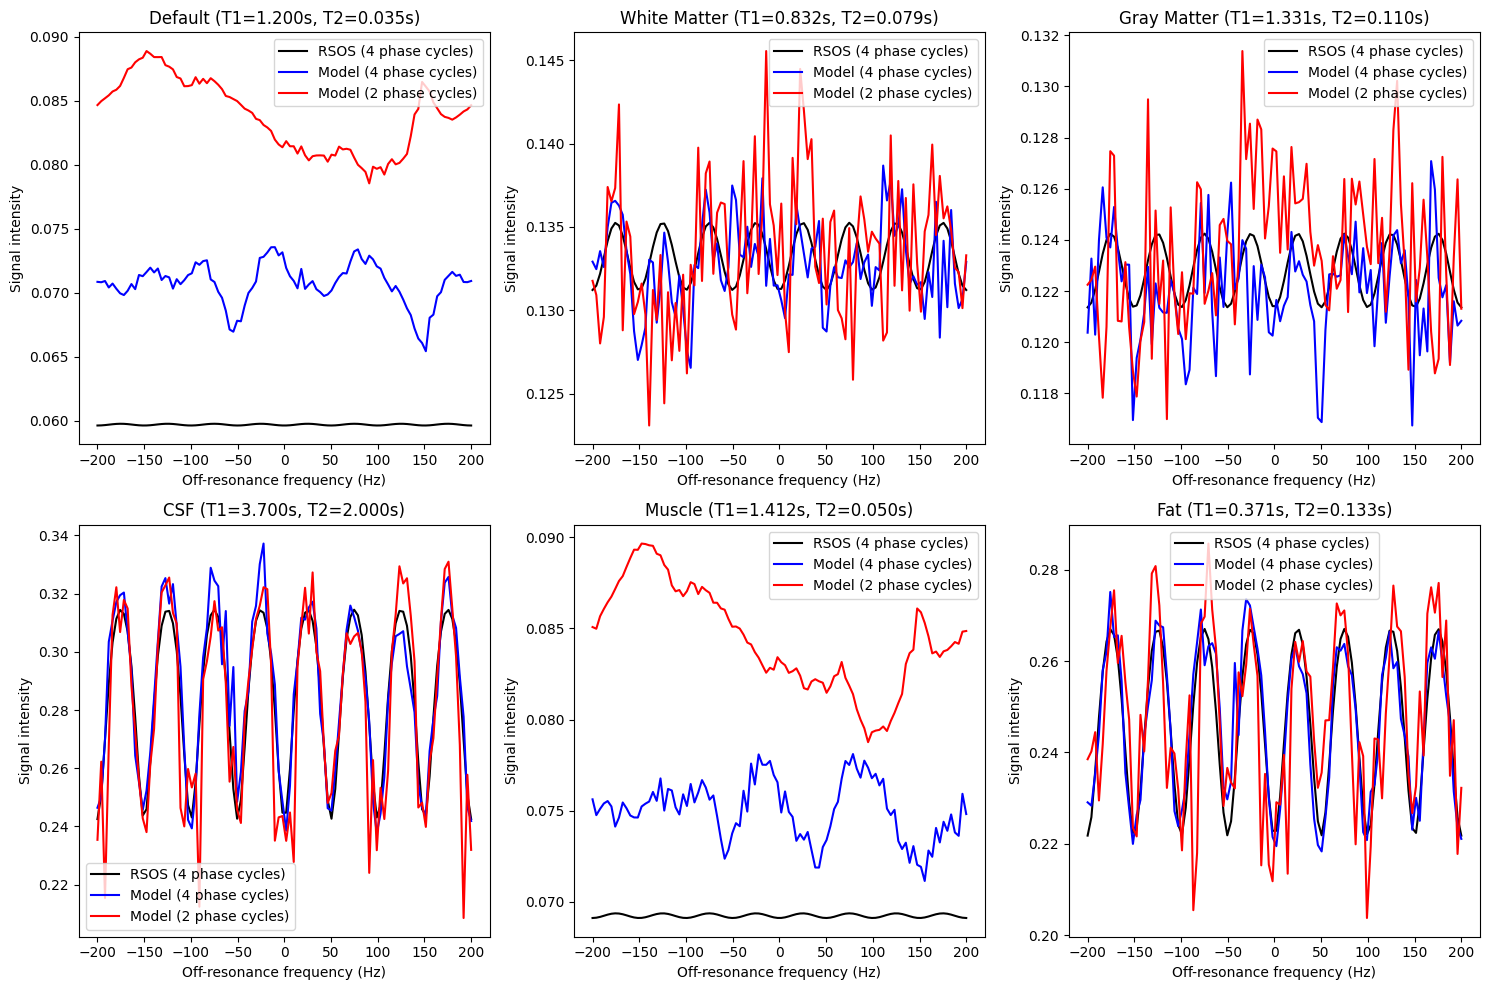

Predicting spectra...
Prediction completed in 10.69 seconds.


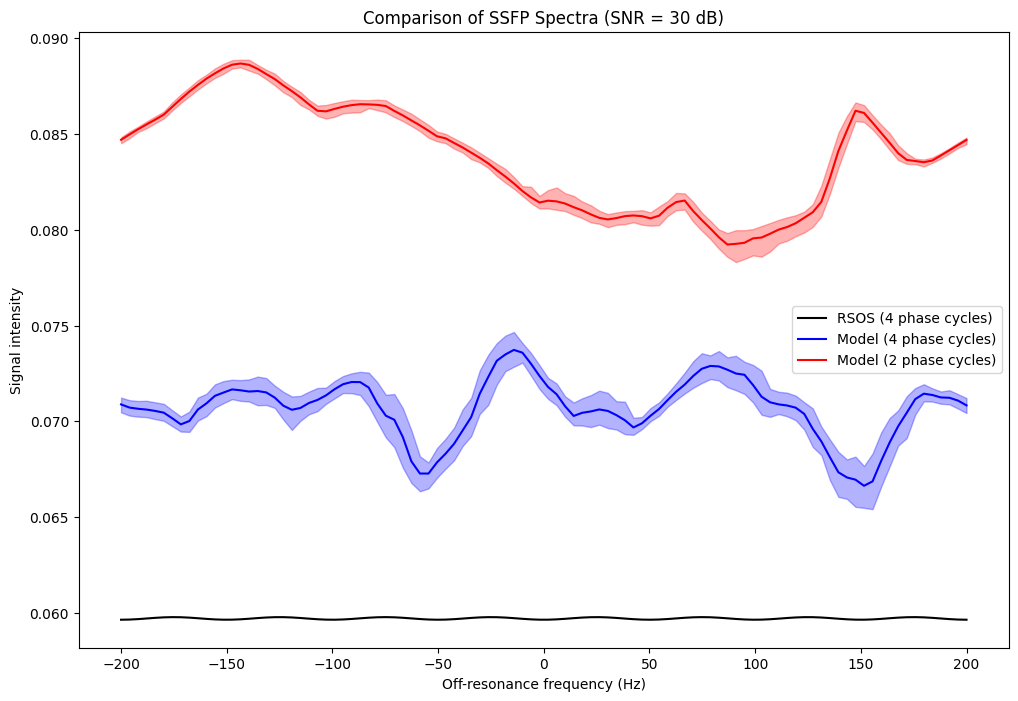

Metrics for 4 phase cycle model:
MSE: 1.23e-04
RMSE: 1.11e-02
MAE: 1.10e-02
R2: -5.28e+04
Correlation: 1.70e-01
NRMSE: 8.17e+01

Metrics for 2 phase cycle model:
MSE: 5.91e-04
RMSE: 2.43e-02
MAE: 2.41e-02
R2: -2.54e+05
Correlation: -4.84e-02
NRMSE: 1.79e+02

Paired t-test results:
t-statistic: -3.20e+03
p-value: 5.32e-250

Dense model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 1.04e-01 - val_loss: 1.44e-02
Epoch 10/200 - loss: 9.38e-04 - val_loss: 3.72e-04
Epoch 20/200 - loss: 6.26e-04 - val_loss: 1.99e-04
Epoch 30/200 - loss: 4.76e-04 - val_loss: 2.60e-04
Epoch 40/200 - loss: 3.74e-04 - val_loss: 1.71e-04
Epoch 50/200 - loss: 3.81e-04 - val_loss: 1.39e-04
Epoch 60/200 - loss: 2.98e-04 - val_loss: 1.08e-04
Epoch 70/200 - loss: 3.10e-04 - val_loss: 1.10e-04
Epoch 80/200 - loss: 2.83e-04 - val_loss: 1.02e-04
Epoch 90/200 - loss: 2.83e-04 - val_loss: 1.22e-04
Epoch 100/200 - loss: 2.84e-04 - val_loss: 6.99e-05
Epoch 110/200 - loss: 2.53e-04 - val_loss: 1.10e-04
Epoch 120

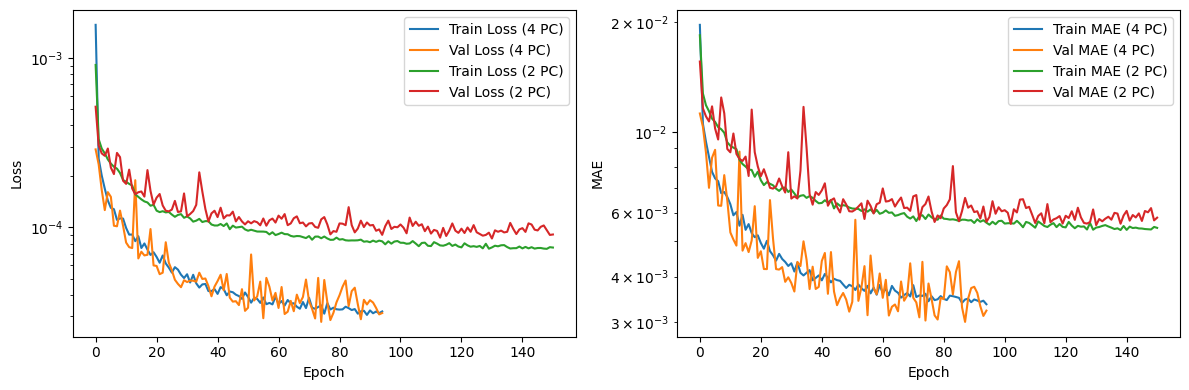

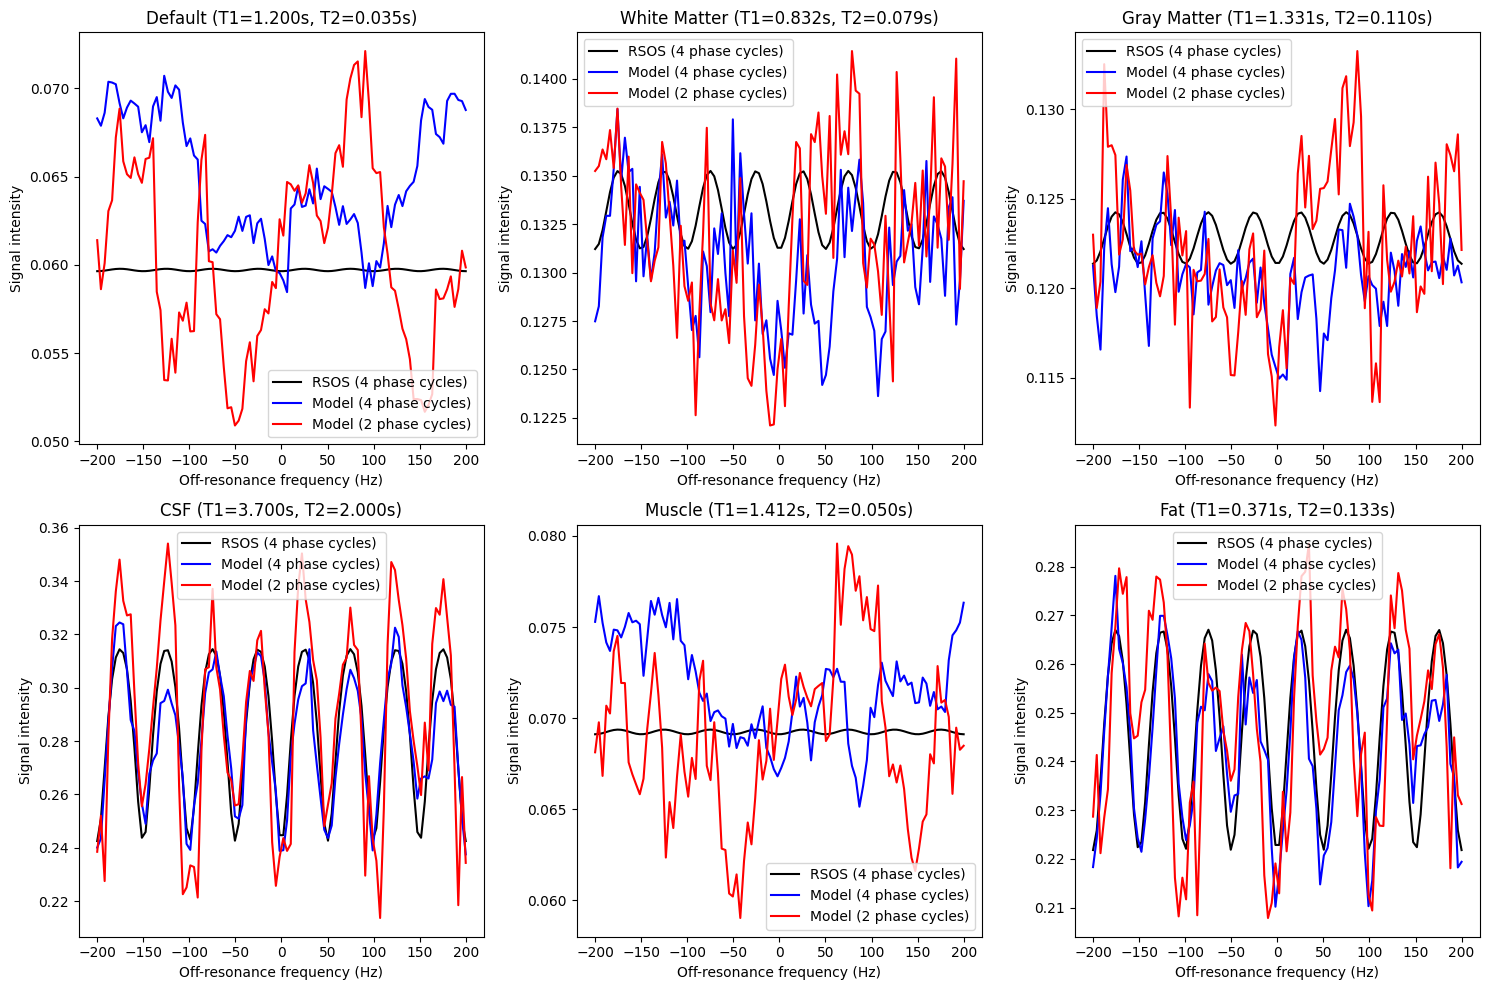

Predicting spectra...
Prediction completed in 11.25 seconds.


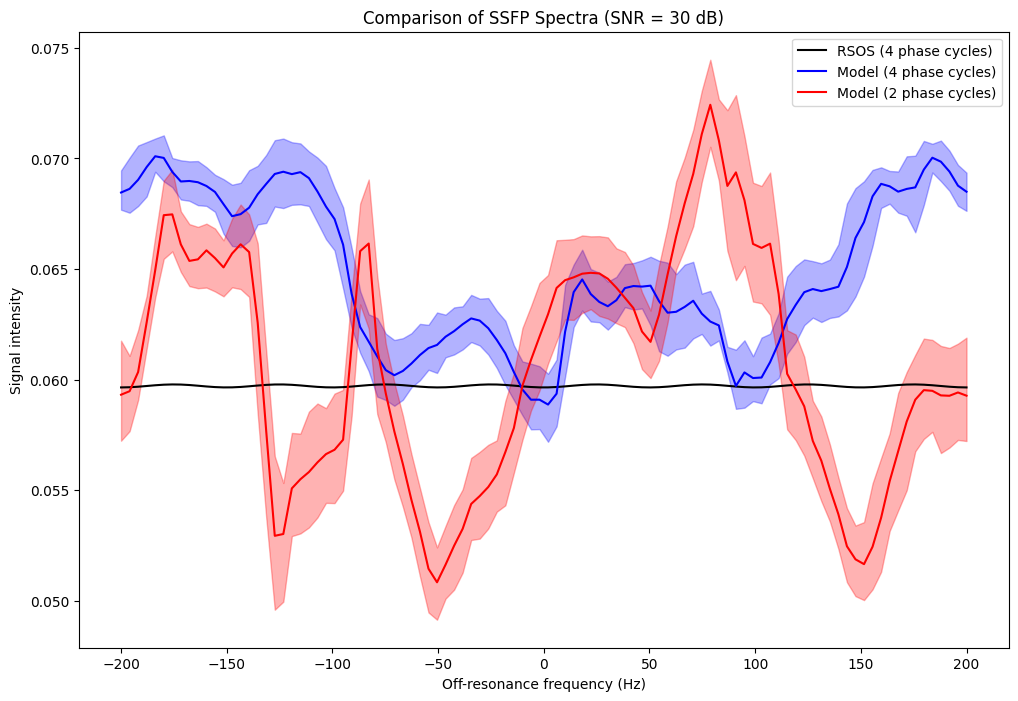

Metrics for 4 phase cycle model:
MSE: 3.83e-05
RMSE: 6.19e-03
MAE: 5.18e-03
R2: -1.65e+04
Correlation: 6.64e-02
NRMSE: 4.57e+01

Metrics for 2 phase cycle model:
MSE: 2.90e-05
RMSE: 5.38e-03
MAE: 4.60e-03
R2: -1.25e+04
Correlation: 1.10e-01
NRMSE: 3.97e+01

Paired t-test results:
t-statistic: 5.55e+01
p-value: 2.04e-76

1DConv model:
Training 4PC model...
Input shape: (8,)
(8,)
Epoch 0/200 - loss: 4.44e-04 - val_loss: 1.11e-04
Epoch 10/200 - loss: 7.17e-05 - val_loss: 7.08e-05
Epoch 20/200 - loss: 5.42e-05 - val_loss: 5.65e-05
Epoch 30/200 - loss: 4.79e-05 - val_loss: 4.90e-05
Epoch 40/200 - loss: 3.80e-05 - val_loss: 4.04e-05
Epoch 50/200 - loss: 3.13e-05 - val_loss: 5.45e-05
Epoch 60/200 - loss: 2.88e-05 - val_loss: 4.50e-05
Completed in 5557.28 seconds.
Training 2PC model...
Input shape: (4,)
(4,)
Epoch 0/200 - loss: 8.50e-04 - val_loss: 4.04e-04
Epoch 10/200 - loss: 1.33e-04 - val_loss: 1.49e-04
Epoch 20/200 - loss: 1.11e-04 - val_loss: 1.19e-04
Epoch 30/200 - loss: 9.93e-05 - val_

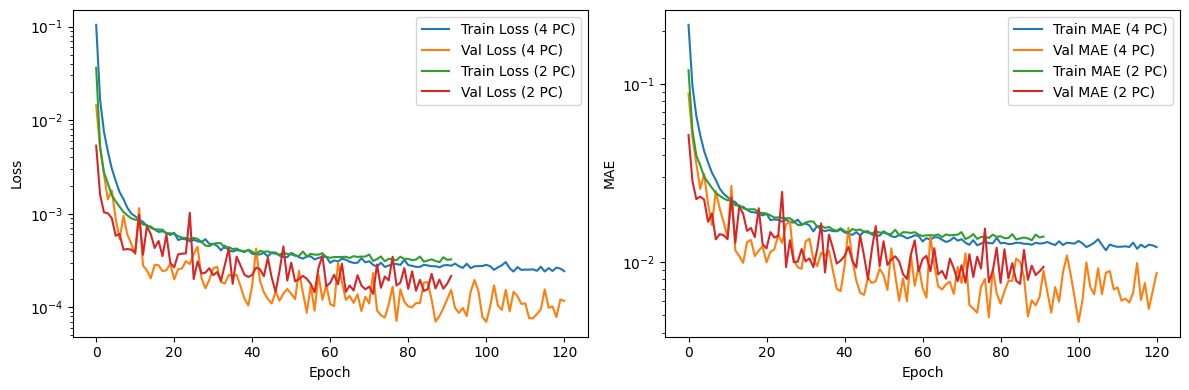

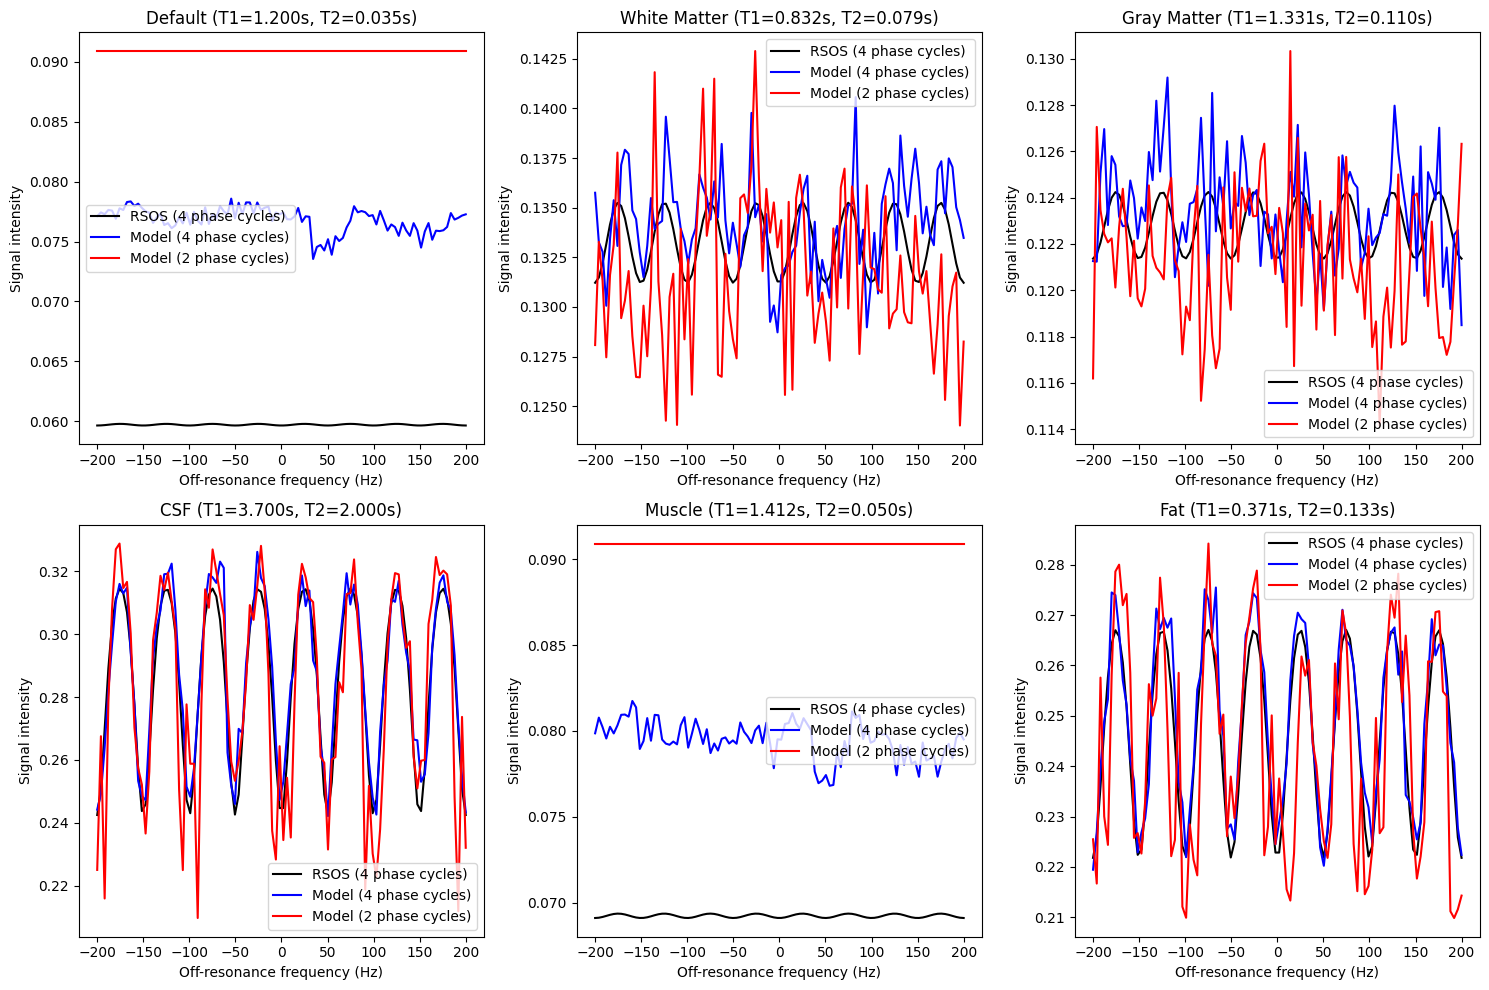

Predicting spectra...
Prediction completed in 25.56 seconds.


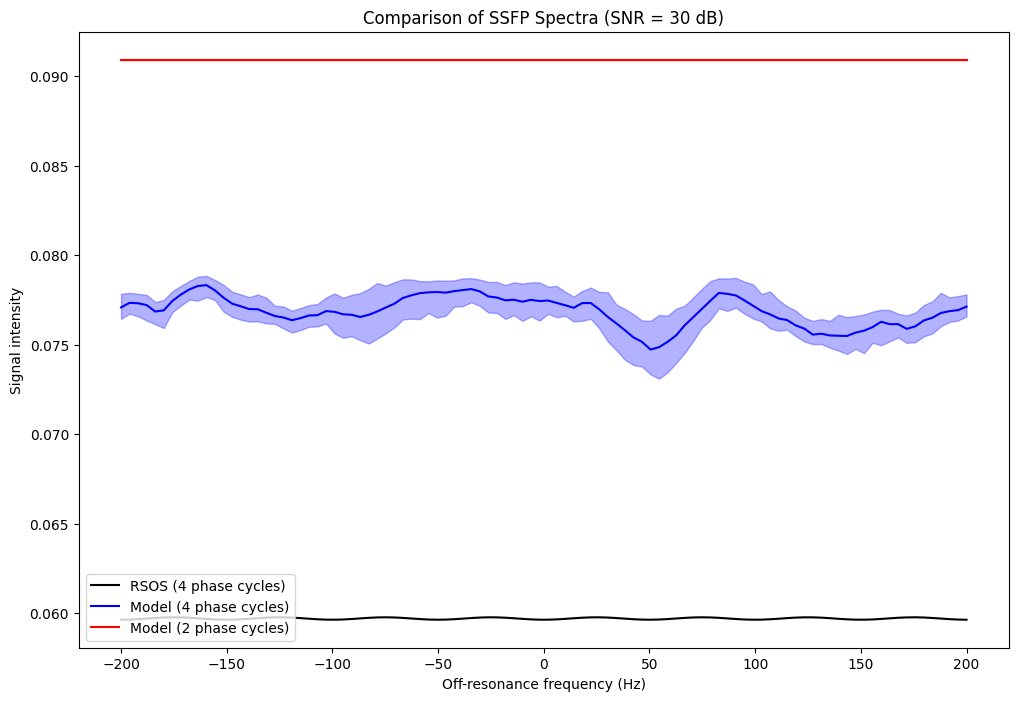

C:\Users\mmend\AppData\Local\Temp\ipykernel_20904\3216557154.py:336: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(y_true_float[valid_indices], y_pred_float[valid_indices])


Metrics for 4 phase cycle model:
MSE: 2.95e-04
RMSE: 1.72e-02
MAE: 1.71e-02
R2: -1.27e+05
Correlation: -1.90e-04
NRMSE: 1.27e+02

Metrics for 2 phase cycle model:
MSE: 9.73e-04
RMSE: 3.12e-02
MAE: 3.12e-02
R2: -4.19e+05
Correlation: nan
NRMSE: 2.30e+02

Paired t-test results:
t-statistic: -4.17e+03
p-value: 1.82e-261

SymmetricConv1D model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 1.05e-03 - val_loss: 3.03e-04
Epoch 10/200 - loss: 1.01e-04 - val_loss: 8.83e-05
Epoch 20/200 - loss: 6.51e-05 - val_loss: 6.29e-05
Epoch 30/200 - loss: 5.62e-05 - val_loss: 4.63e-05
Epoch 40/200 - loss: 4.17e-05 - val_loss: 4.13e-05
Epoch 50/200 - loss: 3.88e-05 - val_loss: 3.38e-05
Epoch 60/200 - loss: 3.79e-05 - val_loss: 5.27e-05
Epoch 70/200 - loss: 3.64e-05 - val_loss: 3.39e-05
Epoch 80/200 - loss: 3.62e-05 - val_loss: 3.17e-05
Epoch 90/200 - loss: 3.28e-05 - val_loss: 4.39e-05
Completed in 7727.44 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 1.74e-03 - val_los

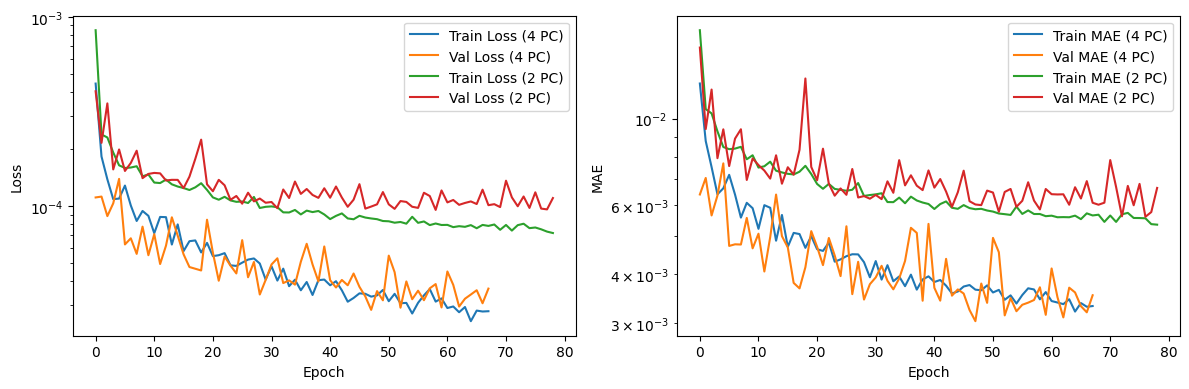

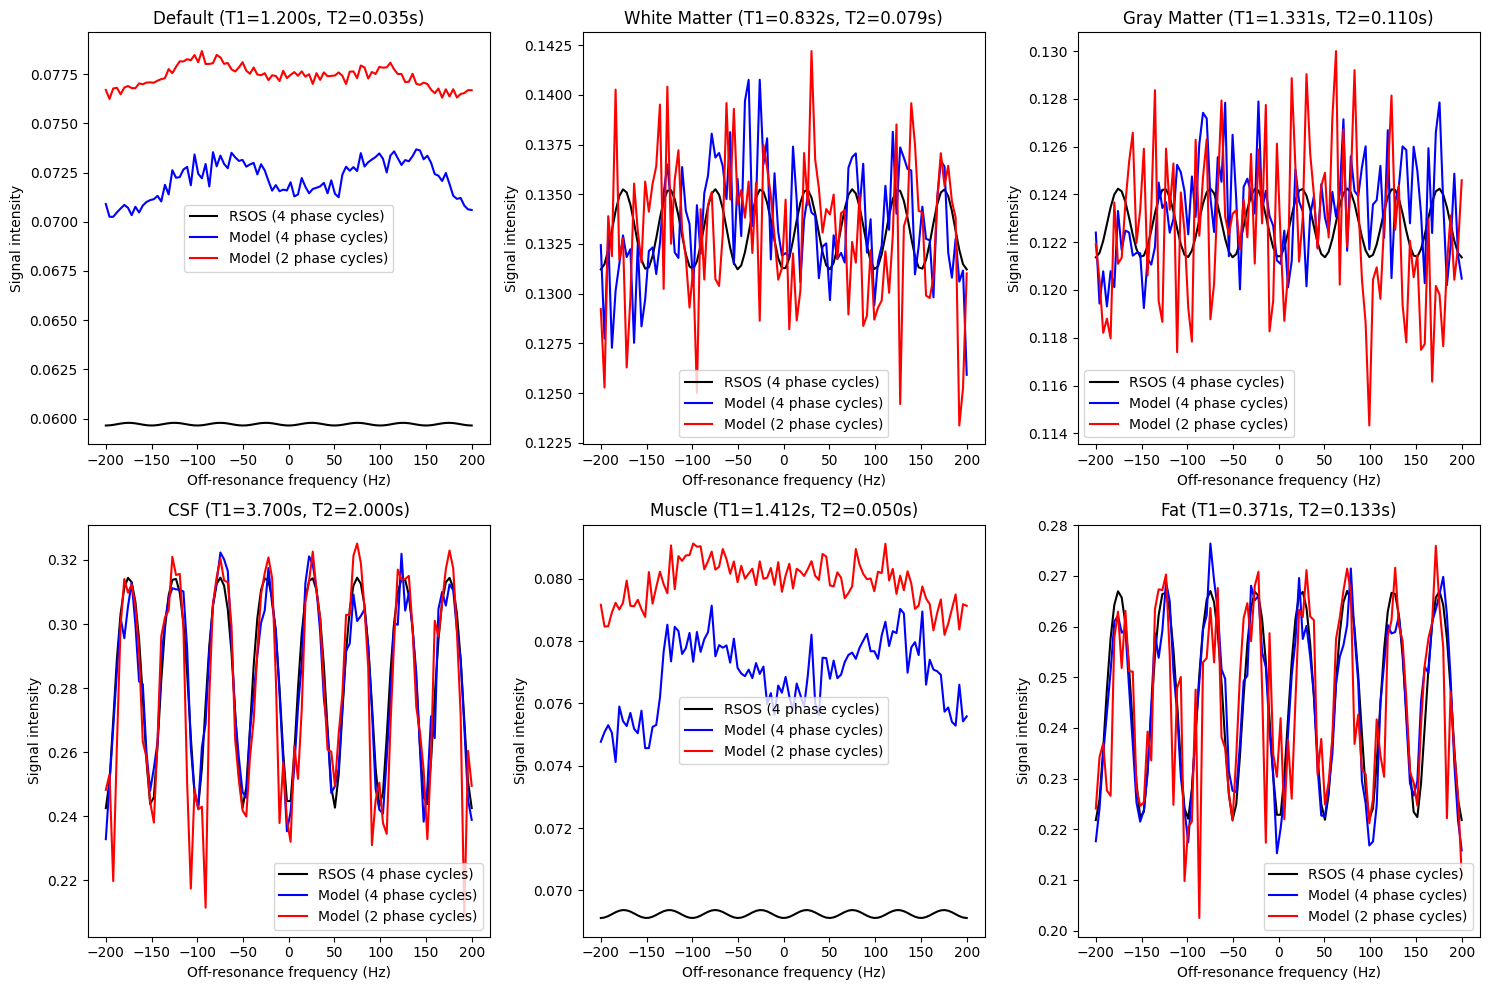

Predicting spectra...
Prediction completed in 37.25 seconds.


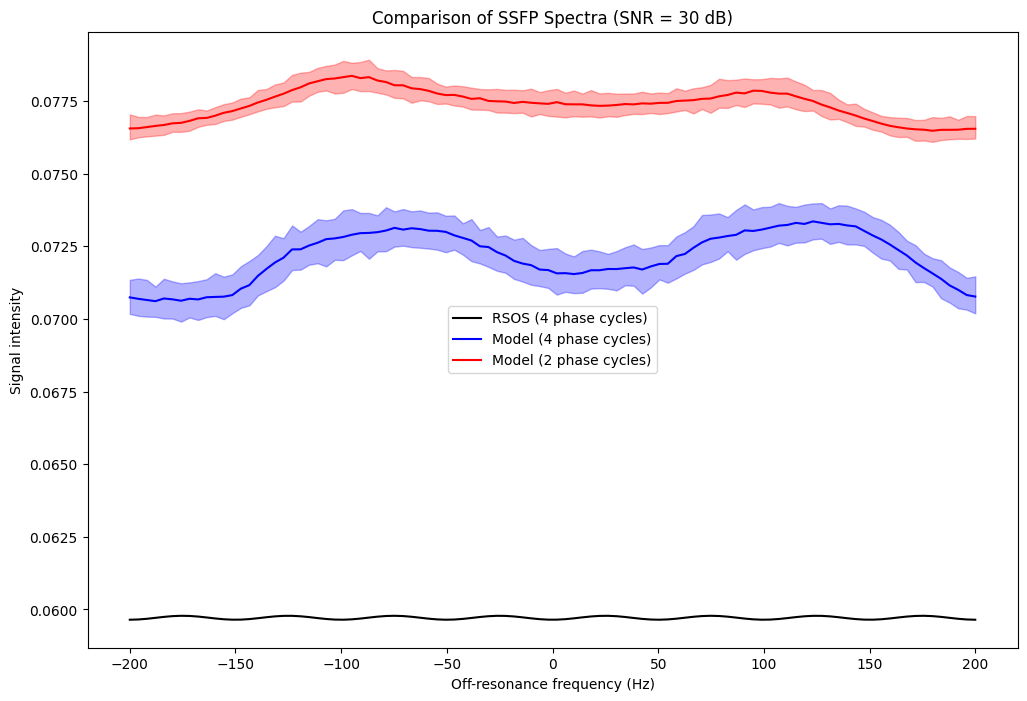

Metrics for 4 phase cycle model:
MSE: 1.56e-04
RMSE: 1.25e-02
MAE: 1.24e-02
R2: -6.71e+04
Correlation: 6.70e-02
NRMSE: 9.20e+01

Metrics for 2 phase cycle model:
MSE: 3.13e-04
RMSE: 1.77e-02
MAE: 1.77e-02
R2: -1.35e+05
Correlation: 2.88e-03
NRMSE: 1.31e+02

Paired t-test results:
t-statistic: -1.36e+03
p-value: 3.35e-213

UNet1DConv model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 1.98e-02 - val_loss: 1.54e-03
Epoch 10/200 - loss: 3.84e-04 - val_loss: 1.31e-04
Epoch 20/200 - loss: 2.25e-04 - val_loss: 1.33e-04
Epoch 30/200 - loss: 2.02e-04 - val_loss: 1.83e-04
Epoch 40/200 - loss: 1.48e-04 - val_loss: 8.67e-05
Epoch 50/200 - loss: 1.17e-04 - val_loss: 6.91e-05
Epoch 60/200 - loss: 9.66e-05 - val_loss: 8.63e-05
Epoch 70/200 - loss: 1.10e-04 - val_loss: 6.69e-05
Epoch 80/200 - loss: 8.06e-05 - val_loss: 5.90e-05
Epoch 90/200 - loss: 6.90e-05 - val_loss: 7.70e-05
Completed in 2837.25 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 2.01e-02 - val_loss

ValueError: x and y must have same first dimension, but have shapes (100,) and (800,)

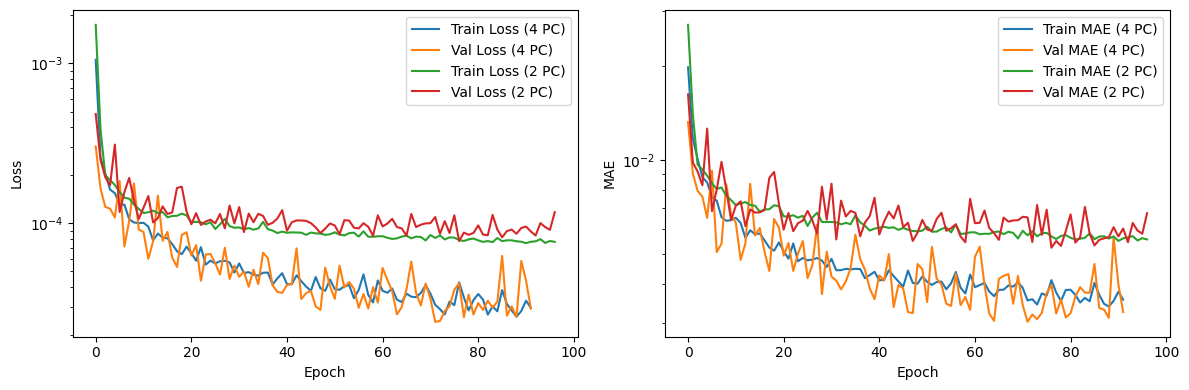

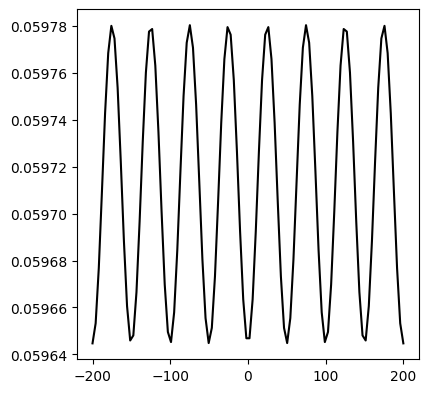

In [109]:
def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Define model architectures
    model_architectures = {
        #'Simple': create_simple_model,
        'Dense': create_dense_model,
        '1DConv': create_1dconv_model,
        'SymmetricConv1D': create_symmetric_conv1d_model,
        #'UNet1DConv': create_unet_1dconv_model,
        #'ResNet': create_resnet_model,
        #'Attention': create_attention_model,
        #'Vit': create_vit_model,
    }

    # Run experiments
    X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc, scaler_4pc, scaler_2pc = generate_datasets(snr, num_samples)
    print(X_4pc_scaled.shape, X_2pc_scaled.shape, y_4pc.shape, y_2pc.shape)

    print("Evaluating models:")
    saved_models = {}
    for name, model in model_architectures.items():
        print(f"\n{name} model:")
        
        models = train_models(model, epochs, batch_size, print_every_n, X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc)
        saved_models[name] = models

        model_4pc = models['4pc'][0]
        model_2pc = models['2pc'][0]
        history_4pc = models['4pc'][1]
        history_2pc = models['2pc'][1]
        print_model_info(model_4pc)

        test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        plot_training_history(history_4pc, history_2pc)
        

    return saved_models

# Main execution
#models = run()

Creating training data...
Completed in 18.19 seconds.
(20000, 8) (20000, 4) (20000,) (20000,)
Evaluating models:

ResNet model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 4.24e-01 - val_loss: 9.71e-02
Epoch 10/200 - loss: 3.78e-03 - val_loss: 1.00e-03
Epoch 20/200 - loss: 1.14e-03 - val_loss: 7.39e-04
Epoch 30/200 - loss: 7.13e-04 - val_loss: 1.41e-04
Epoch 40/200 - loss: 4.51e-04 - val_loss: 2.39e-04
Epoch 50/200 - loss: 4.26e-04 - val_loss: 1.87e-04
Epoch 60/200 - loss: 3.17e-04 - val_loss: 2.29e-04
Epoch 70/200 - loss: 3.21e-04 - val_loss: 1.95e-04
Epoch 80/200 - loss: 2.84e-04 - val_loss: 1.13e-04
Epoch 90/200 - loss: 2.74e-04 - val_loss: 1.10e-04
Epoch 100/200 - loss: 2.86e-04 - val_loss: 8.70e-05
Completed in 114.85 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 2.81e-01 - val_loss: 3.80e-02
Epoch 10/200 - loss: 3.55e-03 - val_loss: 3.22e-03
Epoch 20/200 - loss: 1.23e-03 - val_loss: 1.27e-03
Epoch 30/200 - loss: 6.97e-04 - val_loss: 3.84e-04

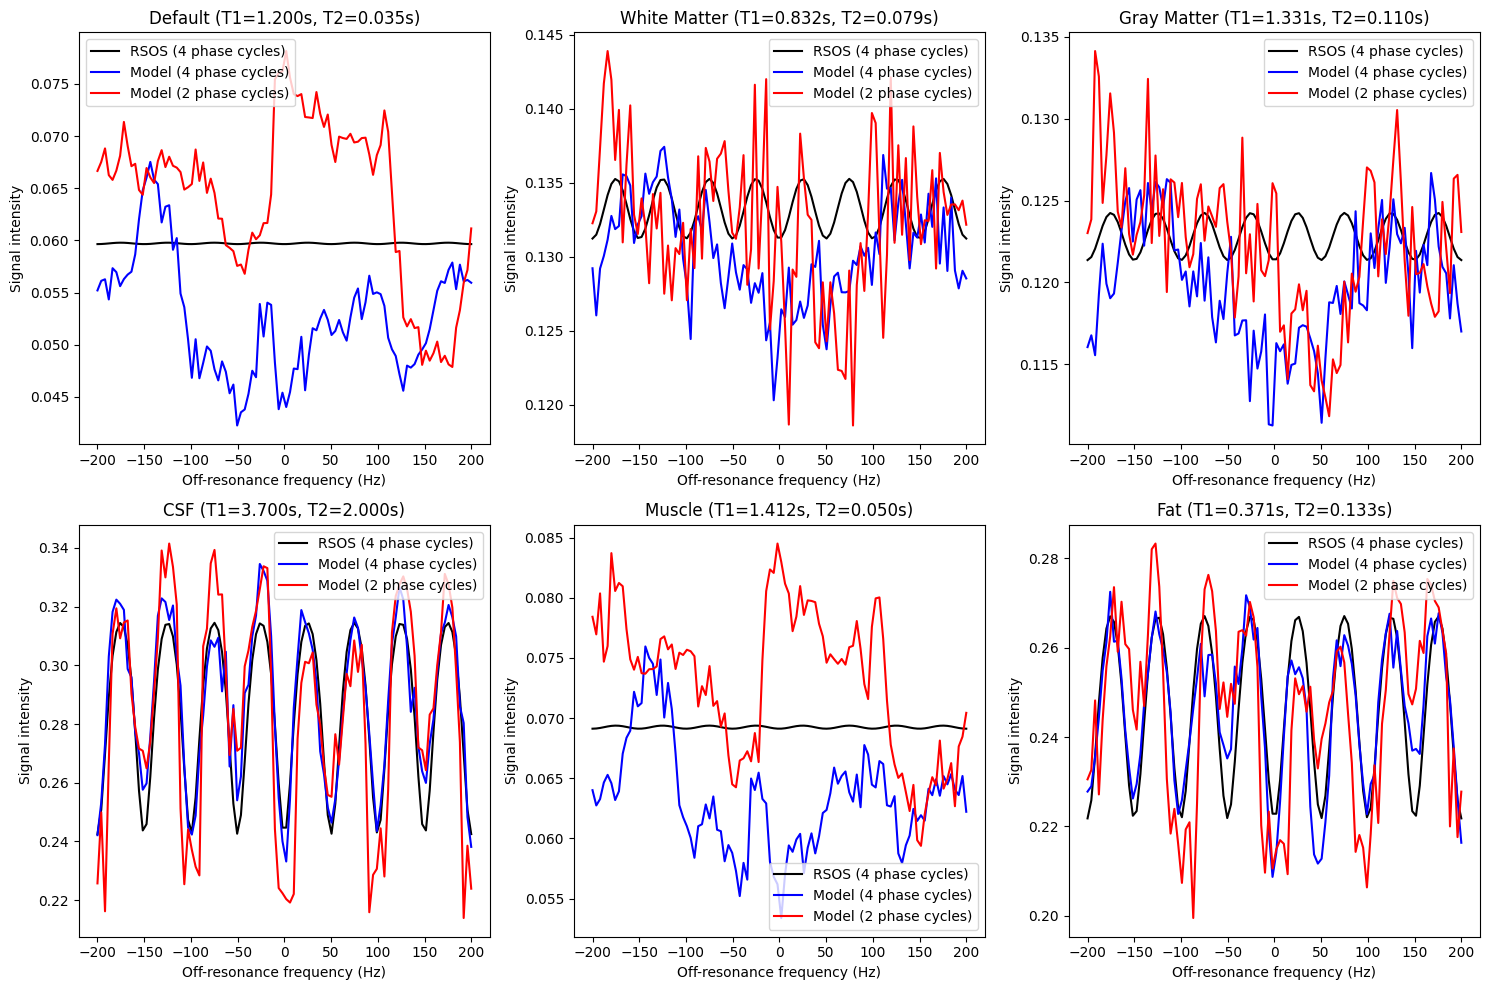

Predicting spectra...
Prediction completed in 10.50 seconds.


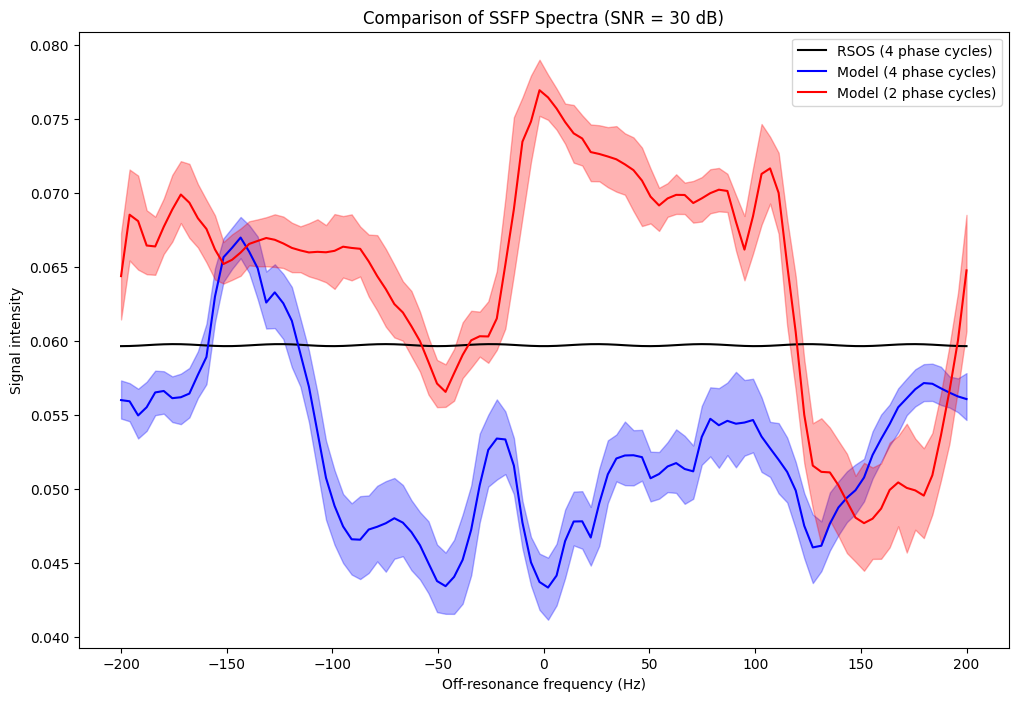

Metrics for 4 phase cycle model:
MSE: 8.20e-05
RMSE: 9.05e-03
MAE: 8.03e-03
R2: -3.53e+04
Correlation: 7.73e-02
NRMSE: 6.68e+01

Metrics for 2 phase cycle model:
MSE: 7.87e-05
RMSE: 8.87e-03
MAE: 7.94e-03
R2: -3.39e+04
Correlation: -6.33e-02
NRMSE: 6.54e+01

Paired t-test results:
t-statistic: 8.27e+00
p-value: 6.25e-13

Attention model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 9.38e-02 - val_loss: 1.55e-02
Epoch 10/200 - loss: 9.69e-04 - val_loss: 5.13e-04
Epoch 20/200 - loss: 6.58e-04 - val_loss: 1.04e-03
Epoch 30/200 - loss: 7.02e-04 - val_loss: 1.26e-03
Epoch 40/200 - loss: 6.14e-04 - val_loss: 6.90e-04
Epoch 50/200 - loss: 6.46e-04 - val_loss: 4.10e-04
Epoch 60/200 - loss: 5.07e-04 - val_loss: 1.74e-04
Epoch 70/200 - loss: 4.42e-04 - val_loss: 1.63e-04
Epoch 80/200 - loss: 4.00e-04 - val_loss: 2.13e-04
Epoch 90/200 - loss: 3.92e-04 - val_loss: 2.03e-04
Completed in 78.04 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 8.17e-02 - val_loss: 1.

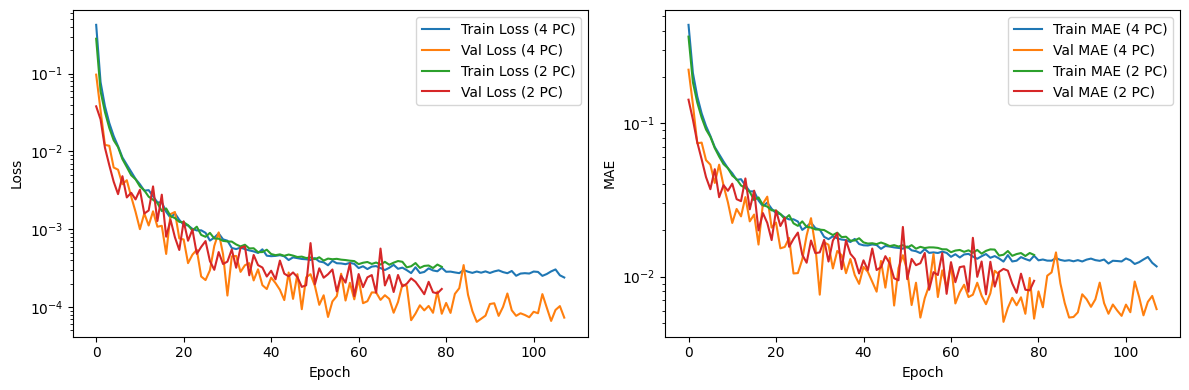

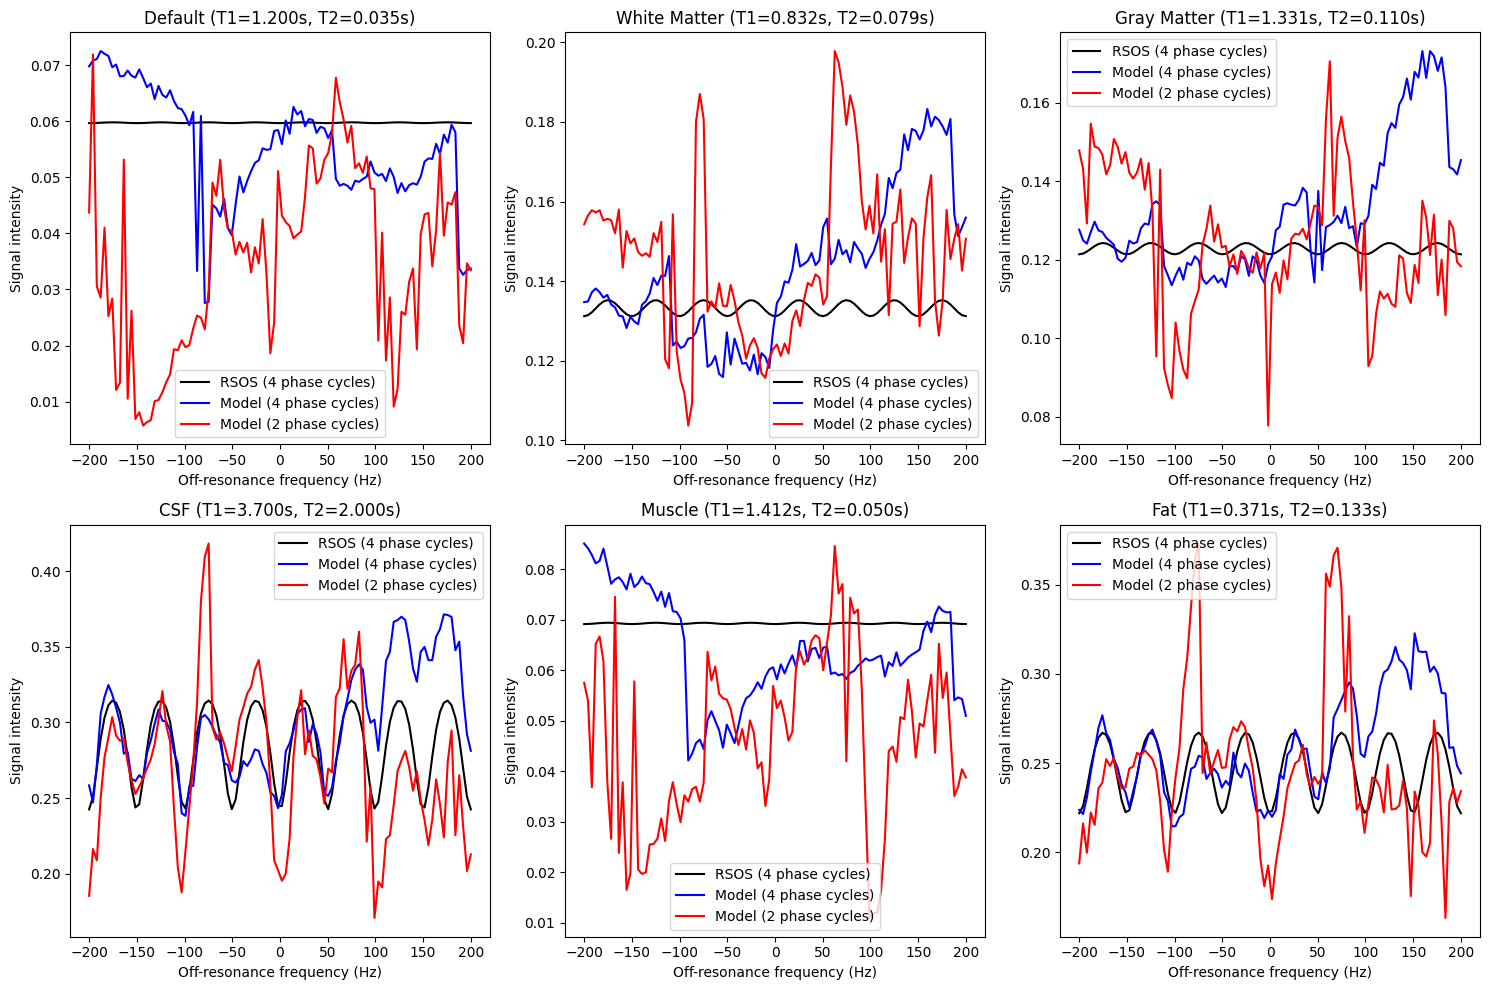

Predicting spectra...
Prediction completed in 11.89 seconds.


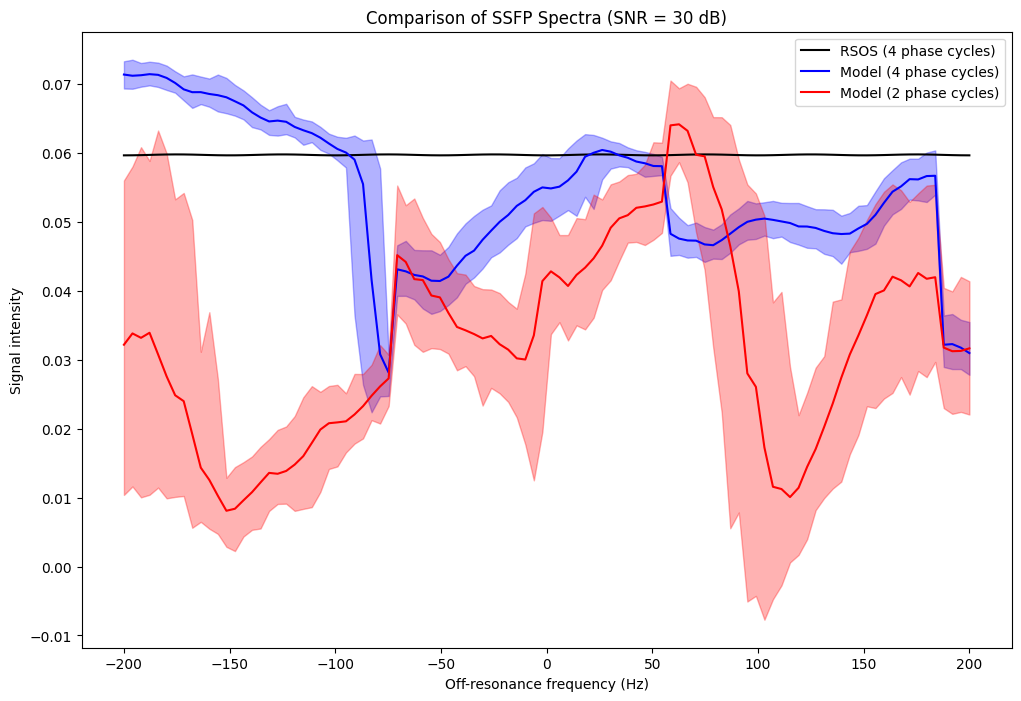

Metrics for 4 phase cycle model:
MSE: 1.36e-04
RMSE: 1.17e-02
MAE: 9.44e-03
R2: -5.87e+04
Correlation: -6.33e-03
NRMSE: 8.61e+01

Metrics for 2 phase cycle model:
MSE: 9.47e-04
RMSE: 3.08e-02
MAE: 2.76e-02
R2: -4.08e+05
Correlation: 5.26e-02
NRMSE: 2.27e+02

Paired t-test results:
t-statistic: -9.06e+01
p-value: 4.56e-97

Vit model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 3.53e-02 - val_loss: 1.62e-03
Epoch 10/200 - loss: 3.23e-04 - val_loss: 2.10e-04
Epoch 20/200 - loss: 3.58e-04 - val_loss: 1.80e-04
Epoch 30/200 - loss: 8.17e-04 - val_loss: 5.83e-04
Epoch 40/200 - loss: 1.81e-04 - val_loss: 1.81e-04
Completed in 200.97 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 3.62e-02 - val_loss: 2.29e-03
Epoch 10/200 - loss: 4.61e-04 - val_loss: 2.64e-04
Epoch 20/200 - loss: 2.88e-04 - val_loss: 4.47e-04
Epoch 30/200 - loss: 2.03e-04 - val_loss: 1.64e-04
Epoch 40/200 - loss: 1.61e-04 - val_loss: 1.43e-04
Epoch 50/200 - loss: 1.45e-04 - val_loss: 1.25e-

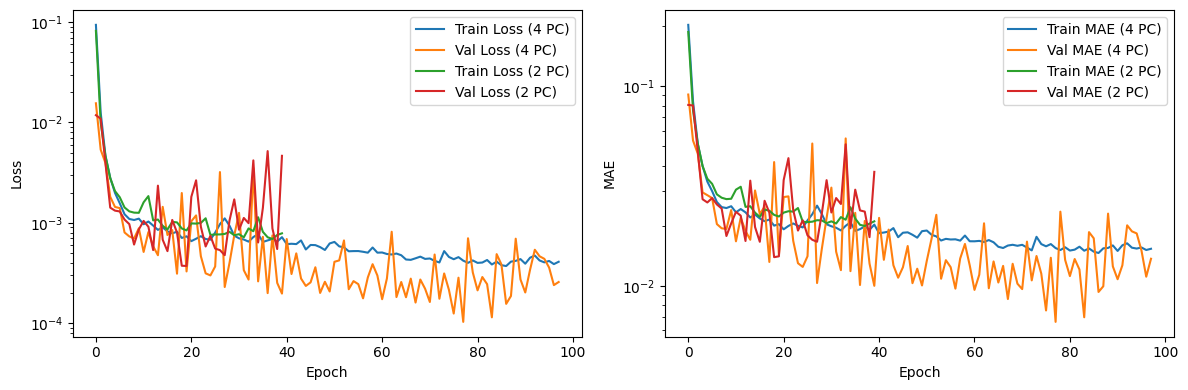

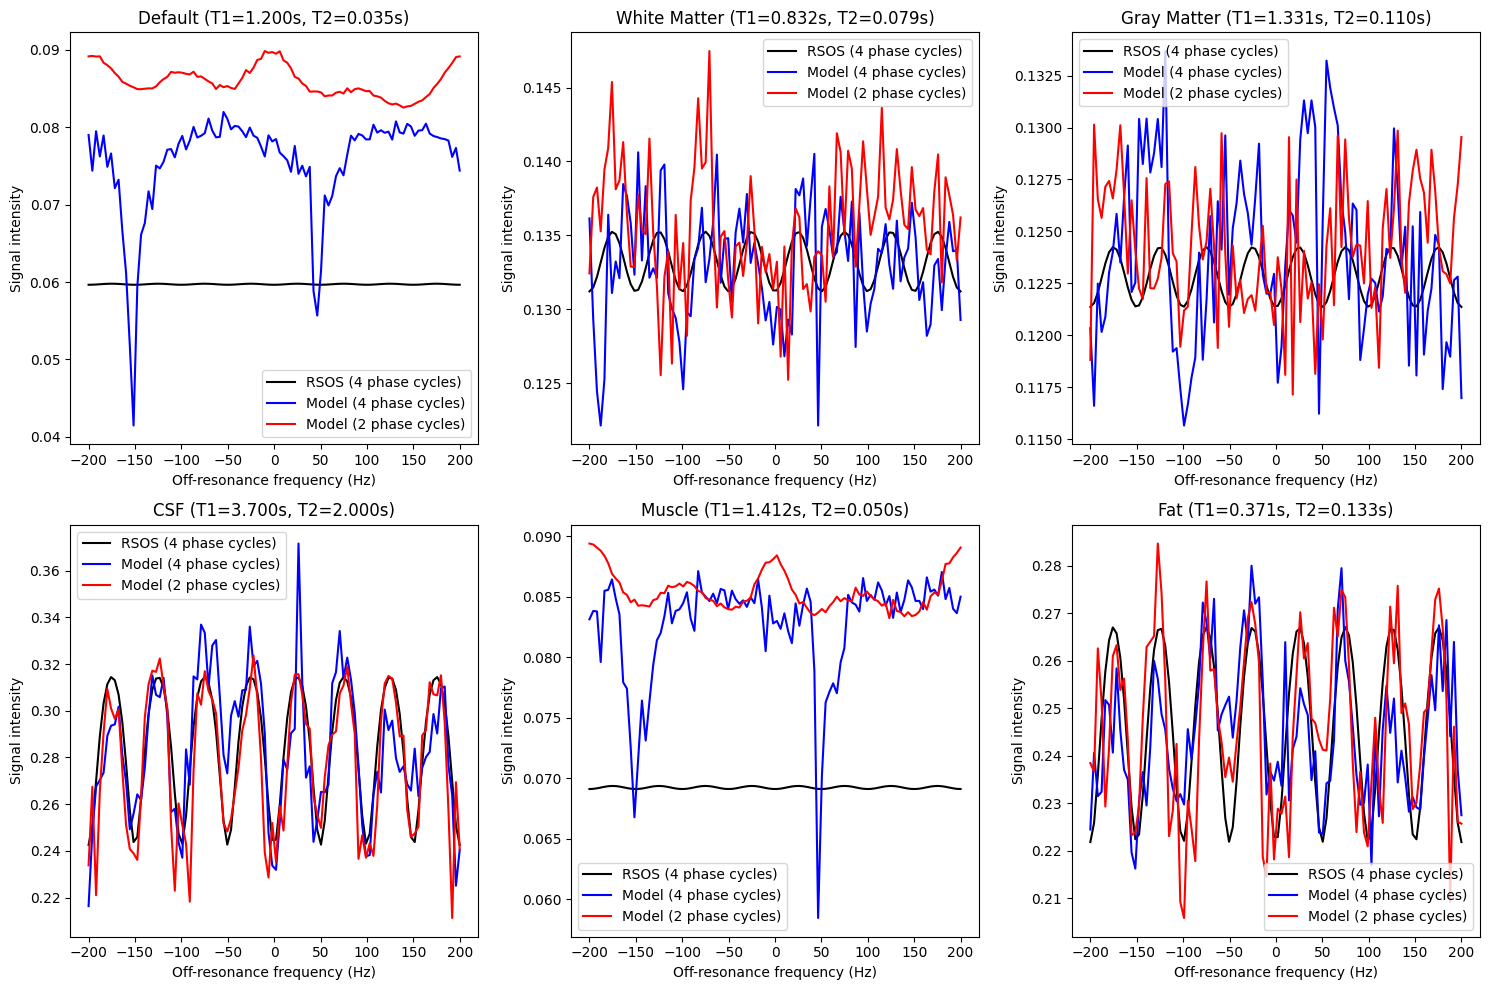

Predicting spectra...
Prediction completed in 11.93 seconds.


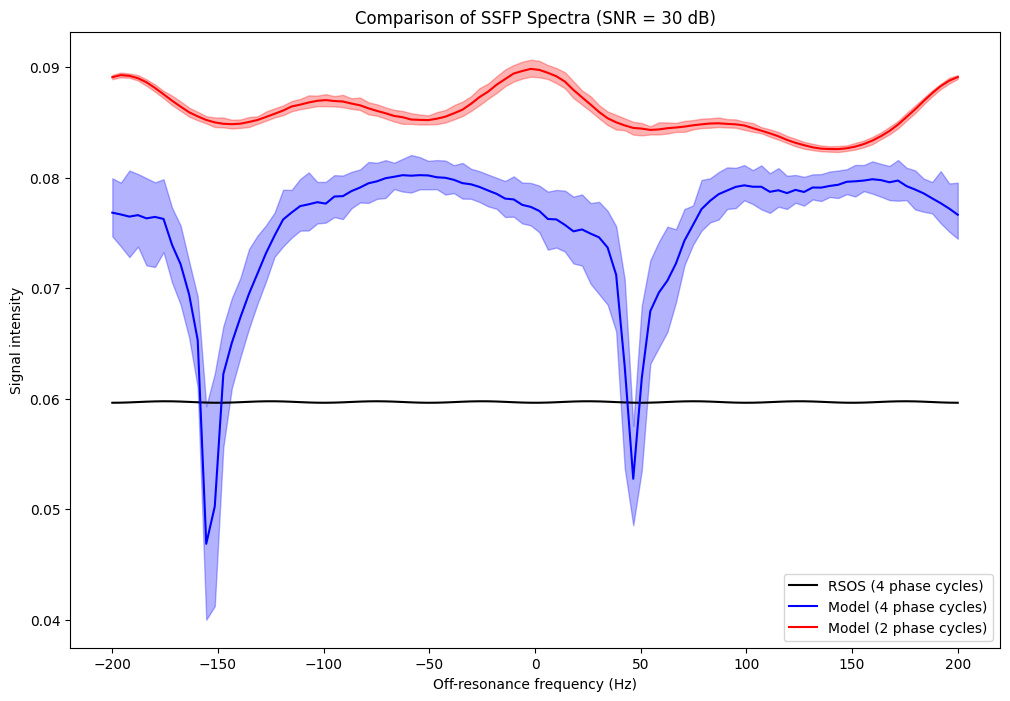

Metrics for 4 phase cycle model:
MSE: 2.91e-04
RMSE: 1.71e-02
MAE: 1.65e-02
R2: -1.26e+05
Correlation: 2.28e-01
NRMSE: 1.26e+02

Metrics for 2 phase cycle model:
MSE: 6.92e-04
RMSE: 2.63e-02
MAE: 2.62e-02
R2: -2.98e+05
Correlation: -5.48e-02
NRMSE: 1.94e+02

Paired t-test results:
t-statistic: -8.83e+02
p-value: 1.06e-194


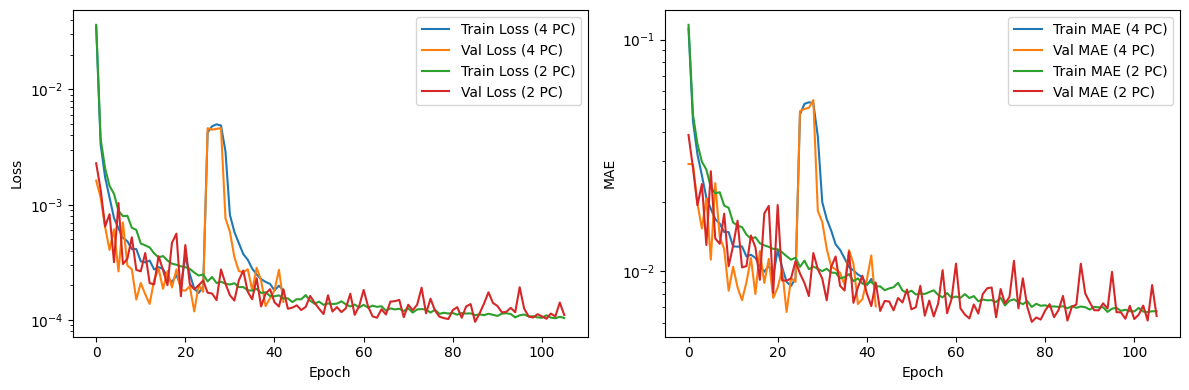

In [5]:
def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Define model architectures
    model_architectures = {
        #'Simple': create_simple_model,
        #'Dense': create_dense_model,
        #'1DConv': create_1dconv_model,
        #'SymmetricConv1D': create_symmetric_conv1d_model,
        #'UNet1DConv': create_unet_1dconv_model,
        'ResNet': create_resnet_model,
        'Attention': create_attention_model,
        'Vit': create_vit_model,
    }

    # Run experiments
    X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc, scaler_4pc, scaler_2pc = generate_datasets(snr, num_samples)
    print(X_4pc_scaled.shape, X_2pc_scaled.shape, y_4pc.shape, y_2pc.shape)

    print("Evaluating models:")
    saved_models = {}
    for name, model in model_architectures.items():
        print(f"\n{name} model:")
        
        models = train_models(model, epochs, batch_size, print_every_n, X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc)
        saved_models[name] = models

        model_4pc = models['4pc'][0]
        model_2pc = models['2pc'][0]
        history_4pc = models['4pc'][1]
        history_2pc = models['2pc'][1]
        print_model_info(model_4pc)

        test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        plot_training_history(history_4pc, history_2pc)
        

    return saved_models

# Main execution
models = run()

Creating training data...
Completed in 9.97 seconds.
(20000, 8) (20000, 4) (20000,) (20000,)
Evaluating models:

Dense model:
Training 4PC model...
Input shape: (8,)
Epoch 0/200 - loss: 7.95e-02 - val_loss: 1.11e-02
Epoch 10/200 - loss: 9.34e-04 - val_loss: 2.71e-04
Epoch 20/200 - loss: 6.18e-04 - val_loss: 3.04e-04
Epoch 30/200 - loss: 4.86e-04 - val_loss: 4.78e-04
Epoch 40/200 - loss: 4.02e-04 - val_loss: 1.69e-04
Epoch 50/200 - loss: 4.12e-04 - val_loss: 1.36e-04
Epoch 60/200 - loss: 3.12e-04 - val_loss: 1.43e-04
Epoch 70/200 - loss: 3.30e-04 - val_loss: 1.09e-04
Epoch 80/200 - loss: 3.01e-04 - val_loss: 1.05e-04
Completed in 65.16 seconds.
Training 2PC model...
Input shape: (4,)
Epoch 0/200 - loss: 6.46e-02 - val_loss: 7.06e-03
Epoch 10/200 - loss: 1.04e-03 - val_loss: 5.15e-04
Epoch 20/200 - loss: 6.60e-04 - val_loss: 2.69e-04
Epoch 30/200 - loss: 4.58e-04 - val_loss: 1.71e-04
Epoch 40/200 - loss: 3.94e-04 - val_loss: 2.41e-04
Epoch 50/200 - loss: 3.76e-04 - val_loss: 2.55e-04
Epo

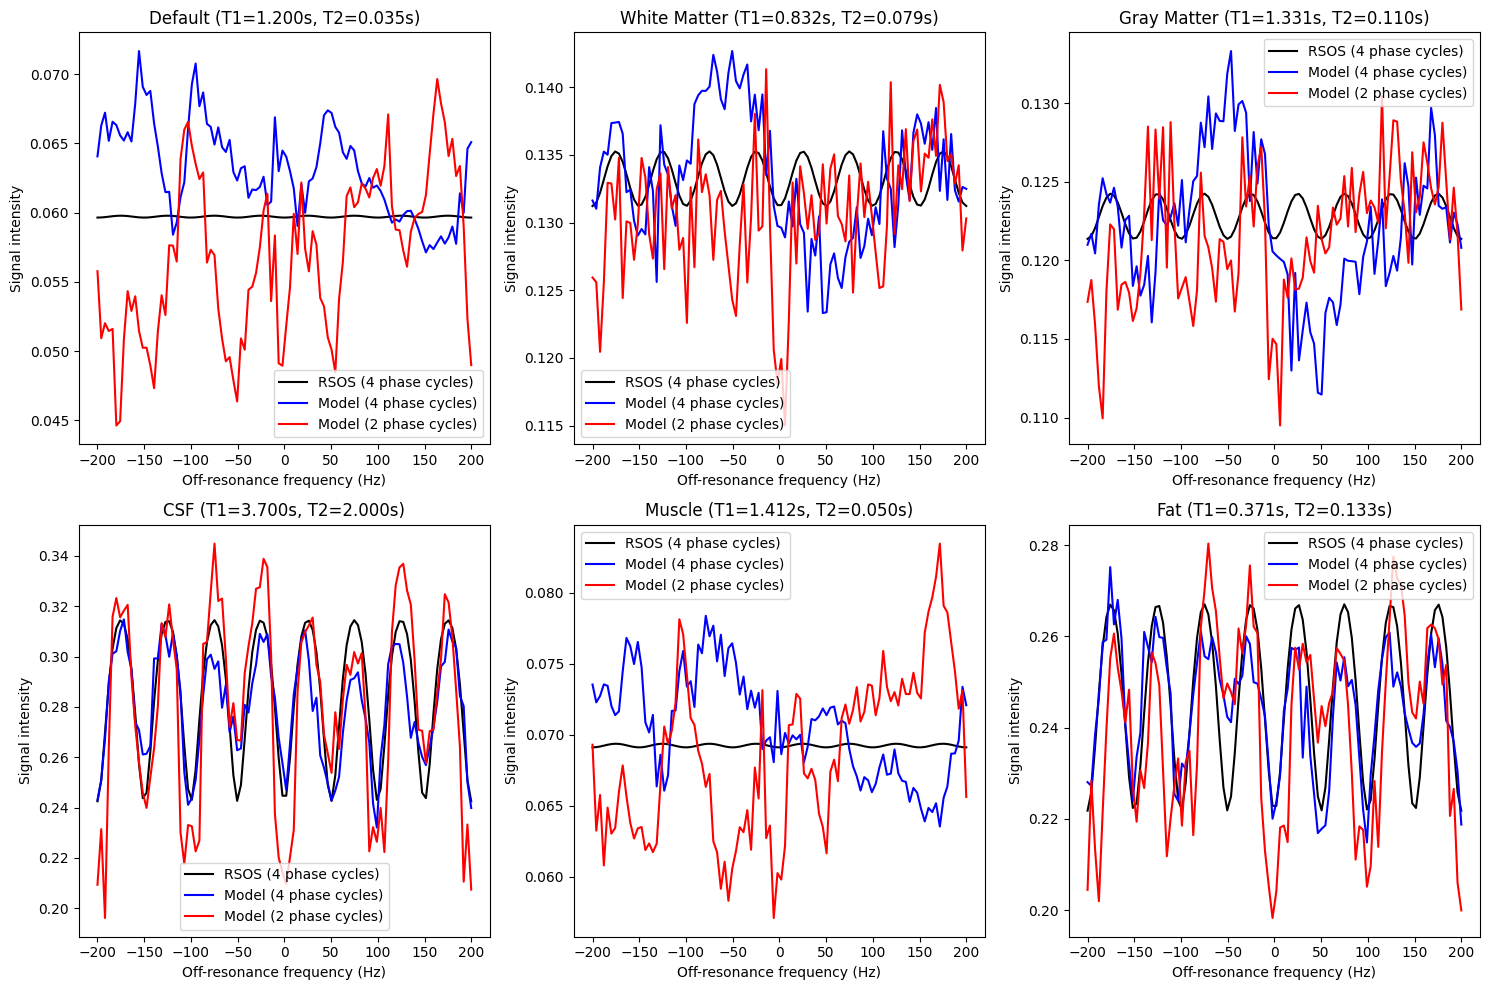

Predicting spectra...
Prediction completed in 10.09 seconds.


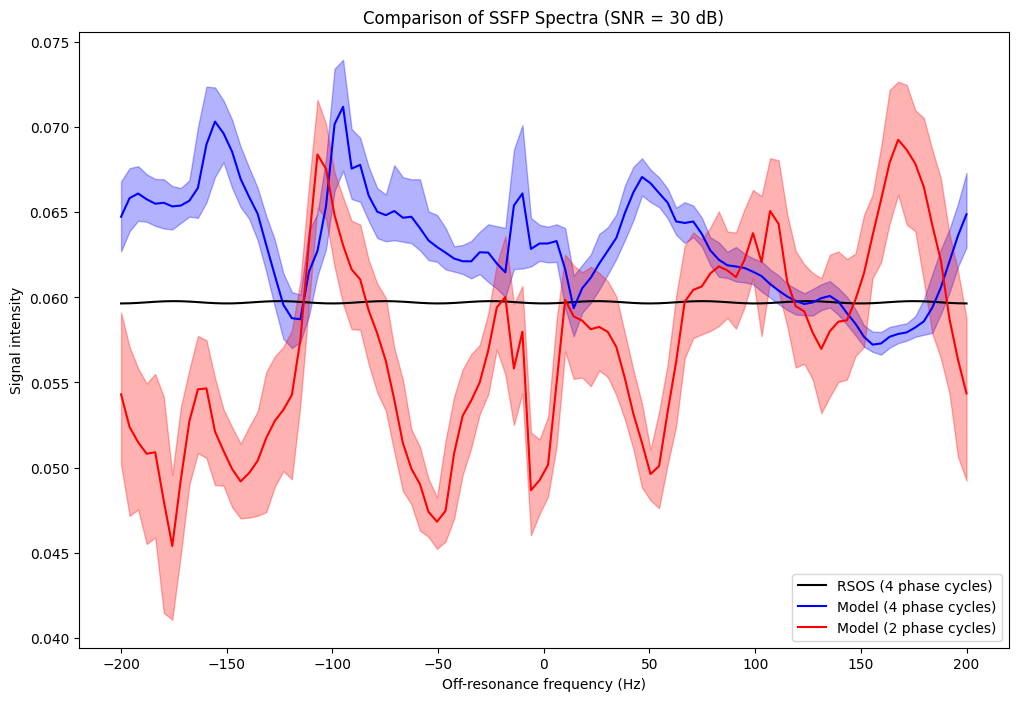

Metrics for 4 phase cycle model:
MSE: 2.16e-05
RMSE: 4.64e-03
MAE: 3.80e-03
R2: -9.29e+03
Correlation: -2.85e-01
NRMSE: 3.42e+01

Metrics for 2 phase cycle model:
MSE: 4.08e-05
RMSE: 6.39e-03
MAE: 5.24e-03
R2: -1.76e+04
Correlation: 1.44e-01
NRMSE: 4.71e+01

Paired t-test results:
t-statistic: -7.80e+01
p-value: 1.01e-90


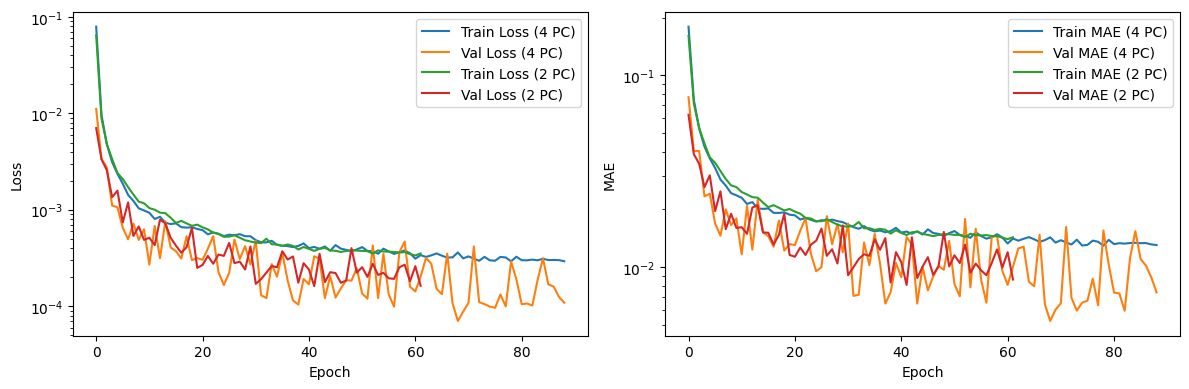

In [7]:
def run(snr = 30, num_samples = 20000, epochs = 200, batch_size = 32, print_every_n = 10):
    # Set random seed for reproducibility
    np.random.seed(42)
    tf.random.set_seed(42)
    
    # Define model architectures
    model_architectures = {
        #'Simple': create_simple_model,
        'Dense': create_dense_model,
        #'Dense2': create_improved_model,
        #'Dense3': create_deep_model,
        #'1DConv': create_1dconv_model,
        #'SymmetricConv1D': create_symmetric_conv1d_model,
        #'UNet1DConv': create_unet_1dconv_model,
        #'ResNet': create_resnet_model,
        #'Attention': create_attention_model,
        #'Vit': create_vit_model,
    }

    # Run experiments
    X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc, scaler_4pc, scaler_2pc = generate_datasets(snr, num_samples)
    print(X_4pc_scaled.shape, X_2pc_scaled.shape, y_4pc.shape, y_2pc.shape)

    print("Evaluating models:")
    saved_models = {}
    for name, model in model_architectures.items():
        print(f"\n{name} model:")
        
        models = train_models(model, epochs, batch_size, print_every_n, X_4pc_scaled, X_2pc_scaled, y_4pc, y_2pc)
        saved_models[name] = models

        model_4pc = models['4pc'][0]
        model_2pc = models['2pc'][0]
        history_4pc = models['4pc'][1]
        history_2pc = models['2pc'][1]
        print_model_info(model_4pc)

        test_model_with_tissues(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        test_model(model_4pc, model_2pc, scaler_4pc, scaler_2pc, snr)
        plot_training_history(history_4pc, history_2pc)
        

    return saved_models

# Main execution
models = run()